# Phonetic-Convergence Proj

이 프로젝트는 음성수렴 현상을 관찰하기 위한 실험입니다.
분석에 관한 코드 및 실행 결과를 정리한 notebook입니다.

## Module import

In [69]:
import parselmouth
from parselmouth import praat
from parselmouth.praat import call
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
#import librosa
#import librosa.display
import sounddevice as sd
from datetime import datetime
from tqdm import tqdm
import seaborn as sns
import matplotlib.patches as patches
from pathlib import Path
from pprint import pprint

In [4]:
# User define module
from enhanced_formant_analysis import EnhancedFormantAnalyzer, logger
from textgrid_io import TextGridReader
from word_tier_generator import WordTierGenerator

## Hyperparameter

In [5]:
F1_MIN, F1_MAX = 200, 1200    # F1 범위 (Hz)
F2_MIN, F2_MAX = 500, 3000   # F2 범위 (Hz)

In [70]:
# 소스 코드 기준 상대 경로를 이용하여 proj_dir 위치 설정.
proj_dir = os.path.join(Path.home(), 'Documents', 'WorkSpace', 'phoneticConvergence')
exp_data_dir = os.path.join(proj_dir, 'data', 'experiment_data')
analysis_dir = os.path.join(proj_dir, 'src', 'analysis')
print(f"proj_dir: {proj_dir}")
print(f"exp_data_dir: {exp_data_dir}")
print(f"analysis_dir: {analysis_dir}")

proj_dir: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence
exp_data_dir: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data
analysis_dir: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/src/analysis


In [7]:
# wav_dir, annotation_dir 위치 지정.
model_dir = os.path.join(exp_data_dir, 'model_talker')
model_wav_dir = os.path.join(model_dir, 'KFA_audio')
model_annotation_dir = os.path.join(model_dir, 'KFA_annotation_edited')

# 파일 리스트 가져오기. (확장자 고려 필수!)
model_audio_list = [file for file in os.listdir(model_wav_dir) if file.endswith(".wav")]
model_annotation_list = [file for file in os.listdir(model_annotation_dir) if file.endswith(".TextGrid")]
model_audio_list.sort()
model_annotation_list.sort()

# 리스트 확인
print(f"model_audio: {len(model_audio_list)}개")
print(f"model_annotation: {len(model_annotation_list)}개")
pprint(f"model_audio_list: {model_audio_list}")
pprint(f"model_annotation_list: {model_annotation_list}")

model_audio: 50개
model_annotation: 50개
("model_audio_list: ['난색.wav', '난파.wav', '내빈.wav', '내사.wav', "
 "'녹각.wav', '논개.wav', '누룩.wav', '누진.wav', '닌자.wav', "
 "'닝닝.wav', '말미.wav', '망루.wav', '매복.wav', '맹호.wav', "
 "'몰딩.wav', '몽매.wav', '무골.wav', '무운.wav', '미비.wav', "
 "'밀사.wav', '박애.wav', '발탁.wav', '백태.wav', '뱃심.wav', "
 "'복시.wav', '봉독.wav', '분개.wav', '불모.wav', '비재.wav', "
 "'빈축.wav', '상기.wav', '상록.wav', '새참.wav', '샐쭉.wav', "
 "'소조.wav', '송부.wav', '수하.wav', '술책.wav', '시문.wav', "
 "'실족.wav', '파군.wav', '판본.wav', '패물.wav', '팽배.wav', "
 "'포문.wav', '폭압.wav', '품띠.wav', '풍산.wav', '피폭.wav', "
 "'필생.wav']")
("model_annotation_list: ['난색.TextGrid', '난파.TextGrid', "
 "'내빈.TextGrid', '내사.TextGrid', '녹각.TextGrid', '논개.TextGrid', "
 "'누룩.TextGrid', '누진.TextGrid', '닌자.TextGrid', '닝닝.TextGrid', "
 "'말미.TextGrid',

In [148]:
# wav_dir, annotation_dir 위치 지정.
participants_dir = os.path.join(exp_data_dir,'results-KFA-reviewed')
participant_list = [file for file in os.listdir(participants_dir) if file.startswith("participant_LY")]
participant_list.sort()

# 리스트 확인
print(f"participant_list: {len(participant_list)}개")
pprint(f"participant_list: {participant_list}")

participant_list: 49개
("participant_list: ['participant_LY002', 'participant_LY004', "
 "'participant_LY005', 'participant_LY006', 'participant_LY007', "
 "'participant_LY008', 'participant_LY009', 'participant_LY010', "
 "'participant_LY011', 'participant_LY013', 'participant_LY015', "
 "'participant_LY017', 'participant_LY019', 'participant_LY020', "
 "'participant_LY021', 'participant_LY022', 'participant_LY023', "
 "'participant_LY024', 'participant_LY026', 'participant_LY027', "
 "'participant_LY028', 'participant_LY029', 'participant_LY030', "
 "'participant_LY031', 'participant_LY032', 'participant_LY033', "
 "'participant_LY034', 'participant_LY035', 'participant_LY036', "
 "'participant_LY037', 'participant_LY038', 'participant_LY039', "
 "'participant_LY040', 'participant_LY041', 'participant_LY042', "
 "'participant_LY044', 'participant_LY045', 'participant_LY046', "
 "'participant_LY047', 'participant_LY048', 'participant_LY050', "
 "'participant_LY051', 'participant_LY053'

## File Validity Check

### File Naming Check

model speaker의 음성 파일 리스트 naming check.

In [7]:
# any를 사용해서 wav 파일들 중 TextGrid랑 pair가 맞지 않는 경우가 있는지 check.
any([True if wav_file_name.replace('.wav', '.TextGrid') not in model_annotation_list else False for wav_file_name in model_audio_list])

False

participant 폴더에서 각 파일들의 naming check

In [8]:
# 모든 참가자 파일에 wav, annotation 파일이 맞게 존재하는지 확인.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_wav_list = [file for file in os.listdir(participant_dir) if file.endswith(".wav")]
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    
    participant_wav_list.sort()
    participant_annotation_list.sort()

    # 각 참가자 당 wav 4개, textgrid 4개가 존재해야 하고, 이름이 동일해야 함.
    if len(participant_wav_list) != 4:
        raise FileNotFoundError(f"Not enough wav files in participant_dir: {participant_dir}")
    if len(participant_annotation_list) != 4:
        raise FileNotFoundError(f"Not enough textgrid files in participant_dir: {participant_dir}")
    
    # 각 참가자 당 wav 4개, textgrid 4개가 존재해야 하고, 이름이 동일해야 함.
    if any([True if wav_file_name.replace('.wav', '.TextGrid') not in participant_annotation_list else False for wav_file_name in participant_wav_list]):
        raise FileNotFoundError(f"wav and textgrid files are not paired in participant_dir: {participant_dir}.")

print("All files are paired correctly.")


Checking validity of participant files: 100%|██████████| 50/50 [00:00<00:00, 13527.39it/s]

All files are paired correctly.


### Boundary Fixation

In [9]:
# 모든 참가자 textgrid 파일에 boundary fixation.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    participant_annotation_list.sort()

    for annotation_file in participant_annotation_list:
        annotation_path = os.path.join(participant_dir, annotation_file)
        # boundary fix
        tg = TextGridReader(annotation_path, fix_boundary_integrity=False, verbose=False)
        tg.boundary_fix(backup=True, inplace=True)

        # redefine Word tier 
        generator = WordTierGenerator(annotation_path, verbose=False)
        generator.add_word_tier_to_textgrid(inplace=True)

    
print("All boundaries of TextGrid files are fixed.")

Checking validity of participant files: 100%|██████████| 52/52 [00:01<00:00, 30.78it/s]

All boundaries of TextGrid files are fixed.


### Word, Phone tier numbering check

textgrid 파일 내의 word, phone tier랑 매칭. phone을 모아서 단어 만들면 그 단어가 word tier에 제대로 존재하는지 check.

뱃심 단어가 문제가 있어 이를 수정.
기존에는 phone tier에 "baedsim"이지만, word_tier에는 "baessim"으로 되어 있어. 모두 "baedsim"으로 통일.

In [76]:
for model_annotation_file in tqdm(model_annotation_list, desc="Checking validity of model speaker files"):
    model_annotation_path = os.path.join(model_annotation_dir, model_annotation_file)
    tg = TextGridReader(model_annotation_path)

    # tier가 2개 인지 check
    if 'phone' not in tg.get_tier_names() or 'word' not in tg.get_tier_names():
        raise TypeError(f"phone or word tier is not found in the TextGrid file.{model_annotation_file}")
    
    # phone tier에서 phone fragment를 추출해서 붙이고, word tier랑 비교.
    phone_fragment = ""
    for interval in tg.get_intervals_by_tier('phone'):
        if interval.text != 'sp':
            phone_fragment += interval.text
    
    word_fragment = ""
    for word_interval in tg.get_intervals_by_tier('word'):
        if word_interval.text != 'sp':
            word_fragment += word_interval.text
    
    if phone_fragment.lower() != word_fragment.lower():
        raise ValueError(f"phones and word are not matched in the TextGrid file.{model_annotation_file}")

print("The word and phone tiers in all model speaker files are matched correctly.")


Checking validity of model speaker files: 100%|██████████| 50/50 [00:00<00:00, 2508.02it/s]

The word and phone tiers in all model speaker files are matched correctly.


참가자 파일도 마찬가지로 check
하다가보면, phone_tier 같은데에서 phone 끝에 spacebar 들어간 경우가 종종 있으니 확인 요망.
-> word tier와 phone tier 간 오탈자 체크

In [ ]:
# 모든 참가자의 textgrid에서 phone, word tier에서 phone 조각들이 제대로 되어 있나 check.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    participant_annotation_list.sort()

    for participant_annotation_file in participant_annotation_list:
        participant_annotation_path = os.path.join(participant_dir, participant_annotation_file)
        tg = TextGridReader(participant_annotation_path)

        if 'phone' not in tg.get_tier_names() or 'word' not in tg.get_tier_names():
            raise TypeError(f"phone or word tier is not found in the TextGrid file.{participant_annotation_file}")

        phone_fragment_Q = []
        phone_fragment = ""
        for interval in tg.get_intervals_by_tier('phone'):
            if interval.text != 'sp':
                phone_fragment += interval.text
            elif interval.text == 'sp' and phone_fragment != "":
                phone_fragment_Q.append(phone_fragment)
                phone_fragment_Q.append("sp")
                phone_fragment = ""
            else:
                phone_fragment_Q.append("sp")
                phone_fragment = ""
        # remainder: sp가 나와야 그 전까지 단어 처리하고 리스트에 추가할 수 있는데, textgrid 마지막에 sp 없이 끝나는 경우.
        if phone_fragment != "":
            phone_fragment_Q.append(phone_fragment)
        
        phone_fragment_df = pd.DataFrame(phone_fragment_Q, columns=['text'])
        phone_fragment_df = phone_fragment_df[phone_fragment_df['text'] != 'sp'].reset_index(drop=True)

        word_df = pd.DataFrame(tg.get_intervals_by_tier('word'))
        word_df = word_df[word_df['text'] != 'sp'].reset_index(drop=True)
        
        if phone_fragment_df.shape[0] != word_df.shape[0]:
            print(f"phones and word are not matched in the TextGrid file.{participant_annotation_file}")
            print(f"phone_fragment_df.shape[0]: {phone_fragment_df.shape[0]}")
            print(f"word_df.shape[0]: {word_df.shape[0]}")

            print(phone_fragment_df['text'].value_counts())
            print(word_df['text'].value_counts())
            raise ValueError(f"phones and word are not matched in the TextGrid file.{participant_annotation_file}")
        else:
            pass
            #print(f"phones and word are matched in the TextGrid file.{participant_annotation_file}")

                
print("All files are paired correctly.")

Checking validity of participant files: 100%|██████████| 4/4 [00:00<00:00, 30.84it/s]

All files are paired correctly.


In [10]:
def checker(participant_id: str, tg_name: str, text: str):
    participant_dir = os.path.join(participants_dir, participant_id)
    participant_annotation_dir = os.path.join(participant_dir, tg_name)
    tg = TextGridReader(participant_annotation_dir)
    pprint(tg.find_intervals_by_text(tier_name='word', text=text))

checker("participant_LY025", "25_stage6_20250407_1938.TextGrid", "sojo")
        

[Interval(xmin=75.34821151263068,
          xmax=75.84884201115933,
          text='sojo',
          interval_number=86)]


그렇다면 단어의 개수는 맞을까? 참가자들이 정말 모든 단어가 제시된거에 맞게 다 발화했을까?
개수가 맞지 않는 참가자들이 어떠한 단어를 몇개 발화했는지 다 체크해보자.

In [58]:
# 모든 참가자의 textgrid에서 phone, word tier에서 phone 조각들이 제대로 되어 있나 check.
for participant_id in tqdm(participant_list, desc="Checking validity of participant files"):
    participant_dir = os.path.join(participants_dir, participant_id)
    
    participant_annotation_list = [file for file in os.listdir(participant_dir) if file.endswith(".TextGrid")]
    participant_annotation_list.sort()

    for participant_annotation_file in participant_annotation_list:

        #excepted_list = ['25_', '26_', '42_']
        excepted_list = []
        if any(excepted_list in participant_annotation_file for excepted_list in excepted_list):
            continue

        participant_annotation_path = os.path.join(participant_dir, participant_annotation_file)
        tg = TextGridReader(participant_annotation_path)
        
        word_df = pd.DataFrame(tg.get_intervals_by_tier('word'))
        word_df = word_df[word_df['text'] != 'sp'].reset_index(drop=True)

        if 'stage2' in participant_annotation_file or 'stage6' in participant_annotation_file:
            correct_total_word_num = 50
            correct_word_repeated_num = 1
        elif 'stage4' in participant_annotation_file or 'stage5' in participant_annotation_file:
            correct_total_word_num = 150
            correct_word_repeated_num = 3
        else:
            raise ValueError(f"stage number is not valid. TextGrid file: {participant_annotation_file}")

        word_count_df = pd.DataFrame({
            'word': word_df['text'].value_counts().index,
            'count': word_df['text'].value_counts().values
        })

        if word_df.shape[0] != correct_total_word_num:
            print(f"missing word in the TextGrid file.{participant_annotation_file}")
            print(f"expected word stimuli number: {correct_total_word_num}")
            print(f"current word count: {word_df.shape[0]}")
            if word_count_df[word_count_df['count'] != correct_word_repeated_num].shape[0] > 0:
                print(word_count_df[word_count_df['count'] != correct_word_repeated_num])
            else:
                print(word_count_df)
            #raise ValueError(f"missing word in the TextGrid file.{participant_annotation_file}")
        else:
            pass
            #print(f"word tier is matched in the TextGrid file.{participant_annotation_file}")
    
#print("All files are paired correctly.")

Checking validity of participant files:  54%|█████▍    | 28/52 [00:00<00:00, 52.51it/s]

missing word in the TextGrid file.25_stage5_20250407_1930.TextGrid
expected word stimuli number: 150
current word count: 142
      word  count
42  siljog      2
43    muun      2
44     sua      2
45  paemul      2
46   pipog      2
47  songbu      2
48  maebog      2
49   pogab      2


Checking validity of participant files: 100%|██████████| 52/52 [00:00<00:00, 55.28it/s]


일단 25번 참가자의 경우에는 5stage 에서 missing이 너무 많아서 분석할 수 없음. 발화가 녹음되지 않음.
26번은 5, 42번의 5는 추가 분절 필요.

25-08-16: boundary-fix -> word_counting까지 함.

## Formant Analysis

### Processing

#### model-speaker

In [ ]:
# model_audio
def demo_usage():
    """
    Demonstration of the enhanced formant analyzer usage.
    This demo now automatically finds and analyzes all vowels in the specified files.
    """
    print("Enhanced Formant Analyzer Demo")
    print("=" * 40)
    
    # --- Configuration ---
    # Adjust these paths to your actual data directories
    proj_dir = os.path.join(Path.home(), "Documents", "WorkSpace", "phoneticConvergence")
    wav_dir = os.path.join(model_dir,"KFA_audio")
    annotation_dir = os.path.join(model_dir, "KFA_annotation_edited")
    
    # List of files to process - 모든 WAV 파일 자동 포함
    wav_files = [f for f in os.listdir(wav_dir) if f.endswith('.wav')]
    file_list = wav_files
    output_excel_name = "model_vowel_formants.xlsx"
    output_excel_path = os.path.join(analysis_dir, output_excel_name)
    
    print(f"Found {len(file_list)} WAV files in {wav_dir}")
    print(f"Files to process: {file_list[:5]}{'...' if len(file_list) > 5 else ''}")
    
    # --- End Configuration ---

    if not os.path.exists(wav_dir) or not os.path.exists(annotation_dir):
        logger.error("Demo directories not found. Please adjust 'wav_dir' and 'annotation_dir' in demo_usage().")
        return

    try:
        # 1. Create analyzer instance
        analyzer = EnhancedFormantAnalyzer(
            wav_dir=wav_dir,
            annotation_dir=annotation_dir,
            file_list=file_list
        )
        
        # 2. Batch analyze all vowels in the file list
        print(f"\nStarting batch analysis for all vowels in {len(file_list)} files...")
        all_vowel_results = analyzer.batch_analyze_all_vowels(gender='male')
        breakpoint()
        
        # 3. Print a summary of the results
        print("\n--- Analysis Summary ---")
        for filename, results in all_vowel_results.items():
            print(f"File: {filename} - Found and analyzed {len(results)} vowels.")
            for interval_key, result in results.items():
                f1_mean = result['statistics']['F1']['mean']
                f2_mean = result['statistics']['F2']['mean']
                print(f"  - Vowel '{result['vowel_label']}' at {result['metadata']['interval'][0]:.3f}s: "
                      f"F1={f1_mean:.1f} Hz, F2={f2_mean:.1f} Hz")

        # 4. Save the detailed results to an Excel file
        if all_vowel_results:
            print(f"\nSaving detailed results to {output_excel_path}...")
            analyzer.save_results_to_xlsx(all_vowel_results, output_excel_path)
        else:
            print("\nNo results to save.")
        
    except FileNotFoundError as e:
        logger.error(f"File not found error: {e}")
        print("Please ensure that the file_list and directories in the demo are correct.")
    except Exception as e:
        logger.error(f"An unexpected error occurred: {e}", exc_info=True)

demo_usage()


2025-09-13 13:50:05,730 - INFO - All 50 file pairs are valid
2025-09-13 13:50:05,731 - INFO - Processing file: 분개.wav
2025-09-13 13:50:05,731 - INFO - TextGrid 파일 파싱 시작: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data/model_talker/KFA_annotation_edited/분개.TextGrid
2025-09-13 13:50:05,732 - INFO - 파싱 완료: 2개 tier, 총 8개 interval
2025-09-13 13:50:05,732 - INFO - Found 2 vowel intervals in 분개.TextGrid
2025-09-13 13:50:05,733 - INFO - Analyzed vowel 'u' in word 'BUNGAE' (interval 2) at 0.091-0.163s
2025-09-13 13:50:05,736 - INFO - Analyzed vowel 'ae' in word 'BUNGAE' (interval 5) at 0.323-0.537s
2025-09-13 13:50:05,736 - INFO - Processing file: 상록.wav
2025-09-13 13:50:05,736 - INFO - TextGrid 파일 파싱 시작: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data/model_talker/KFA_annotation_edited/상록.TextGrid
2025-09-13 13:50:05,737 - INFO - 파싱 완료: 2개 tier, 총 9개 interval
2025-09-13 13:50:05,737 - INFO - Found 2 vowel intervals 

Enhanced Formant Analyzer Demo
Found 50 WAV files in /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data/model_talker/KFA_audio
Files to process: ['분개.wav', '상록.wav', '밀사.wav', '무골.wav', '패물.wav']...

Starting batch analysis for all vowels in 50 files...


2025-09-13 13:50:05,931 - INFO - Analyzed vowel 'o' in word 'MAENGHO' (interval 5) at 0.282-0.537s
2025-09-13 13:50:05,933 - INFO - Processing file: 미비.wav
2025-09-13 13:50:05,934 - INFO - TextGrid 파일 파싱 시작: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data/model_talker/KFA_annotation_edited/미비.TextGrid
2025-09-13 13:50:05,938 - INFO - 파싱 완료: 2개 tier, 총 9개 interval
2025-09-13 13:50:05,939 - INFO - Found 2 vowel intervals in 미비.TextGrid
2025-09-13 13:50:05,943 - INFO - Analyzed vowel 'i' in word 'MIBI' (interval 3) at 0.067-0.164s
2025-09-13 13:50:05,951 - INFO - Analyzed vowel 'i' in word 'MIBI' (interval 5) at 0.248-0.536s
2025-09-13 13:50:05,952 - INFO - Processing file: 풍산.wav
2025-09-13 13:50:05,953 - INFO - TextGrid 파일 파싱 시작: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data/model_talker/KFA_annotation_edited/풍산.TextGrid
2025-09-13 13:50:05,958 - INFO - 파싱 완료: 2개 tier, 총 9개 interval
2025-09-13 13:50:05,962 - I


--- Analysis Summary ---
File: 분개.wav - Found and analyzed 2 vowels.
  - Vowel 'u' at 0.091s: F1=285.5 Hz, F2=1513.5 Hz
  - Vowel 'ae' at 0.323s: F1=373.4 Hz, F2=2061.8 Hz
File: 상록.wav - Found and analyzed 2 vowels.
  - Vowel 'a' at 0.102s: F1=588.9 Hz, F2=1548.7 Hz
  - Vowel 'o' at 0.302s: F1=403.1 Hz, F2=644.3 Hz
File: 밀사.wav - Found and analyzed 2 vowels.
  - Vowel 'i' at 0.062s: F1=313.8 Hz, F2=1908.2 Hz
  - Vowel 'a' at 0.312s: F1=595.4 Hz, F2=978.1 Hz
File: 무골.wav - Found and analyzed 2 vowels.
  - Vowel 'u' at 0.115s: F1=276.1 Hz, F2=566.1 Hz
  - Vowel 'o' at 0.253s: F1=378.1 Hz, F2=695.1 Hz
File: 패물.wav - Found and analyzed 2 vowels.
  - Vowel 'ae' at 0.053s: F1=455.9 Hz, F2=1891.7 Hz
  - Vowel 'u' at 0.223s: F1=376.7 Hz, F2=598.8 Hz
File: 송부.wav - Found and analyzed 2 vowels.
  - Vowel 'o' at 0.123s: F1=410.2 Hz, F2=650.5 Hz
  - Vowel 'u' at 0.351s: F1=350.5 Hz, F2=1100.9 Hz
File: 내빈.wav - Found and analyzed 2 vowels.
  - Vowel 'ae' at 0.077s: F1=428.3 H

#### participant

수정 방향 phone -> word tier

In [ ]:
def demo_usage():
    """
    Demonstration of the enhanced formant analyzer usage with mid-point analysis.
    This demo now automatically finds and analyzes all vowels in the specified files.
    """
    print("Enhanced Formant Analyzer Demo with Mid-point Analysis")
    print("=" * 60)
    
    # --- Configuration ---
    # Adjust these paths to your actual data directories
    proj_dir = Path.home() / "Documents" / "WorkSpace" / "phoneticConvergence"
    wav_dir = os.path.join(proj_dir,"data/experiment_data/results-KFA-reviewed")
    annotation_dir = os.path.join(proj_dir,"data/experiment_data/model_talker/KFA_annotation_edited")
    
    # Load gender information from survey
    survey_path = os.path.join(proj_dir, "data/experiment_data/survey-latest.xlsx")
    gender_info = {}
    
    try:
        import pandas as pd
        survey_df = pd.read_excel(survey_path)
        for _, row in survey_df.iterrows():
            participant = row['1. 참가자 번호']
            gender = row['Gender']
            if pd.notna(participant) and pd.notna(gender):
                gender_info[participant] = gender
        print(f"Loaded gender information for {len(gender_info)} participants")
    except Exception as e:
        print(f"Warning: Could not load gender information: {e}")
        gender_info = {}
    
    # Collect all WAV files from participant directories
    all_wav_files = []
    participant_gender_map = {}
    
    print("Collecting WAV files from participant directories...")
    participant_dirs = [d for d in os.listdir(wav_dir) if os.path.isdir(os.path.join(wav_dir, d)) and d.startswith('participant_')]
    
    for participant_dir in tqdm(participant_dirs, desc="Scanning participants"):
        participant_path = os.path.join(wav_dir, participant_dir)
        participant_id = participant_dir.replace('participant_', '')
        
        # Get gender for this participant
        # participant_id is in format 'LY044', but we need to match with survey data
        gender = gender_info.get(participant_id, 'male')  # default to male if not found
        participant_gender_map[participant_id] = gender
        
        # Find WAV files in this participant's directory
        wav_files = [f for f in os.listdir(participant_path) if f.endswith('.wav')]
        for wav_file in wav_files:
            full_path = os.path.join(participant_dir, wav_file)
            all_wav_files.append((full_path, participant_id, gender, participant_path))
    
    print(f"Found {len(all_wav_files)} WAV files from {len(participant_gender_map)} participants")
    print(f"Participants: {list(participant_gender_map.keys())[:10]}{'...' if len(participant_gender_map) > 10 else ''}")
    
    # --- End Configuration ---

    if not os.path.exists(wav_dir):
        logger.error("Demo directory not found. Please adjust 'wav_dir' in demo_usage().")
        return

    try:
        all_results = {}
        
        # Process each WAV file with its corresponding gender
        print(f"\nStarting analysis of {len(all_wav_files)} WAV files...")
        for wav_file, participant_id, gender, participant_path in tqdm(all_wav_files, desc="Analyzing WAV files"):
            # Create analyzer instance for this file with participant-specific paths
            analyzer = EnhancedFormantAnalyzer(
                wav_dir=participant_path,
                annotation_dir=participant_path,
                file_list=[os.path.basename(wav_file)]
            )
            
            # Analyze vowels for this file
            file_results = analyzer.analyze_all_vowels_in_file(os.path.basename(wav_file), gender=gender)
            if file_results:
                all_results[wav_file] = file_results
        
        # Print a summary of the results with mid-point information
        print("\n--- Analysis Summary with Mid-point Values ---")
        total_vowels = 0
        for filename, results in tqdm(all_results.items(), desc="Generating summary"):
            vowel_count = len(results)
            total_vowels += vowel_count
            # Find participant and gender info by matching the filename
            participant_id = 'Unknown'
            gender = 'Unknown'
            for full_path, pid, g, _ in all_wav_files:
                if filename == full_path:
                    participant_id = pid
                    gender = g
                    break
            print(f"File: {os.path.basename(filename)} (Participant: {participant_id}, Gender: {gender}) - Found and analyzed {vowel_count} vowels.")
            
            # Show mid-point values for first few vowels as example
            for i, (interval_key, result) in enumerate(results.items()):
                if i < 2:  # Show first 2 vowels as example
                    if 'mid_point' in result and 'formants' in result['mid_point']:
                        f1_mid = result['mid_point']['formants'].get('F1', 'N/A')
                        f2_mid = result['mid_point']['formants'].get('F2', 'N/A')
                        vowel_label = result.get('vowel_label', 'Unknown')
                        print(f"  - Vowel '{vowel_label}' mid-point: F1={f1_mid:.1f}Hz, F2={f2_mid:.1f}Hz")

        print(f"\nTotal vowels analyzed: {total_vowels}")

        # Save the detailed results to an Excel file
        if all_results:
            output_excel_path = "formant_results_all_vowels_with_midpoint_zscore.xlsx"
            print(f"\nSaving detailed results with mid-point values and individual z-scores to {output_excel_path}...")
            
            # Create a temporary analyzer for saving
            temp_analyzer = EnhancedFormantAnalyzer(
                wav_dir=wav_dir,
                annotation_dir=annotation_dir,
                file_list=[]
            )
            temp_analyzer.save_results_to_xlsx(all_results, output_excel_path, participant_gender_map)
            print("Z-score normalization applied: Individual participant normalization for F1 and F2 mid-point values")
        else:
            print("\nNo results to save.")
        
    except FileNotFoundError as e:
        logger.error(f"File not found error: {e}")
        print("Please ensure that the directories in the demo are correct.")
    except Exception as e:
        logger.error(f"An unexpected error occurred: {e}", exc_info=True)


if __name__ == "__main__":
    demo_usage()


Enhanced Formant Analyzer Demo
Loaded gender information for 59 participants


Scanning participants: 100%|██████████| 49/49 [00:00<00:00, 8904.33it/s]


Found 196 WAV files from 49 participants
Participants: ['LY044', 'LY017', 'LY028', 'LY010', 'LY026', 'LY019', 'LY021', 'LY042', 'LY045', 'LY020']...

Starting analysis of 196 WAV files...


Analyzing WAV files:   0%|          | 0/196 [00:00<?, ?it/s]2025-09-13 14:04:31,289 - INFO - All 1 file pairs are valid
2025-09-13 14:04:31,289 - INFO - TextGrid 파일 파싱 시작: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/data/experiment_data/results-KFA-reviewed/participant_LY044/LY044_stage4_20250509_1516.TextGrid
2025-09-13 14:04:31,296 - INFO - 파싱 완료: 2개 tier, 총 1220개 interval
2025-09-13 14:04:31,299 - INFO - Found 300 vowel intervals in LY044_stage4_20250509_1516.TextGrid
2025-09-13 14:04:31,307 - INFO - Analyzed vowel 'ae' in word 'baedsim' (interval 3) at 3.223-3.292s
2025-09-13 14:04:31,311 - INFO - Analyzed vowel 'i' in word 'baedsim' (interval 6) at 3.573-3.633s
2025-09-13 14:04:31,315 - INFO - Analyzed vowel 'ae' in word 'saeljjug' (interval 10) at 5.043-5.123s
2025-09-13 14:04:31,319 - INFO - Analyzed vowel 'u' in word 'saeljjug' (interval 13) at 5.423-5.473s
2025-09-13 14:04:31,323 - INFO - Analyzed vowel 'a' in word 'pagun' (interval 17) at 6.732-6.793s
2025-09-13


--- Analysis Summary ---


Generating summary: 100%|██████████| 196/196 [00:00<00:00, 51567.15it/s]
2025-09-13 14:08:24,070 - INFO - All 0 file pairs are valid


File: participant_LY044/LY044_stage4_20250509_1516.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY044/LY044_stage2_20250509_1514.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 100 vowels.
File: participant_LY044/LY044_stage6_20250509_1525.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 100 vowels.
File: participant_LY044/LY044_stage5_20250509_1521.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY017/17_stage5_20250404_1645.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY017/17_stage4_20250404_1641.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 300 vowels.
File: participant_LY017/17_stage6_20250404_1650.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 100 vowels.
File: participant_LY017/17_stage2_20250404_1639.wav (Participant: Unknown, Gender: Unknown) - Found and analyzed 

2025-09-13 14:08:41,616 - INFO - Results for 39200 vowels saved to /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/src/analysis/formant_results_all_vowels.xlsx with individual z-score normalization


### Visualization & Analysis

In [71]:
model_formant_df_path = os.path.join(analysis_dir,'model_vowel_formants.xlsx')
participant_formant_df_path = os.path.join(analysis_dir,'formant_results_all_vowels_with_midpoint_zscore.xlsx')
print(f"model_formant_df_path: {model_formant_df_path}")
print(f"participant_formant_df_path: {participant_formant_df_path}")
model_formant_df = pd.read_excel(model_formant_df_path) 
participant_formant_df = pd.read_excel(participant_formant_df_path)

model_formant_df_path: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/src/analysis/model_vowel_formants.xlsx
participant_formant_df_path: /Users/bagjuhyeon/Documents/WorkSpace/phoneticConvergence/src/analysis/formant_results_all_vowels_with_midpoint_zscore.xlsx


In [74]:
model_formant_df.head()

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
0,0,분개.wav,BUNGAE,u,2,0.091104,0.162634,0.071530,M,0.333333,...,2569.337579,4102.728475,4,4022.358191,4022.358191,28.848336,3993.509855,4051.206527,2,u_0.0911
1,0,분개.wav,BUNGAE,ae,5,0.322500,0.537378,0.214878,M,0.771429,...,3202.273594,4069.556889,27,4123.624818,4113.847177,49.268794,4046.667956,4217.052405,17,ae_0.3225
2,0,상록.wav,SANGROG,a,2,0.102500,0.132500,0.030000,M,0.200000,...,3608.083082,3608.083082,1,NaN,NaN,NaN,NaN,NaN,0,a_0.1025
3,0,상록.wav,SANGROG,o,5,0.302500,0.372500,0.070000,M,0.333333,...,3288.673539,3476.409946,4,3961.641085,3974.187581,116.749679,3818.964073,4079.225104,4,o_0.3025
4,0,밀사.wav,MILSA,i,2,0.062500,0.182500,0.120000,M,0.600000,...,3156.742856,3285.510270,12,3974.235500,3982.056469,24.393794,3915.346452,4002.360891,12,i_0.0625


In [75]:
model_formant_df.columns

Index(['participant_id', 'file_id', 'word_label', 'vowel_label',
       'interval_number', 'start_time', 'end_time', 'duration', 'gender',
       'success_rate', 'mid_point_time', 'F1_mid_point', 'F2_mid_point',
       'F3_mid_point', 'F4_mid_point', 'F5_mid_point', 'F1_mid_point_zscore',
       'F2_mid_point_zscore', 'F1_mean', 'F1_median', 'F1_std', 'F1_min',
       'F1_max', 'F1_count', 'F2_mean', 'F2_median', 'F2_std', 'F2_min',
       'F2_max', 'F2_count', 'F3_mean', 'F3_median', 'F3_std', 'F3_min',
       'F3_max', 'F3_count', 'F4_mean', 'F4_median', 'F4_std', 'F4_min',
       'F4_max', 'F4_count', 'F5_mean', 'F5_median', 'F5_std', 'F5_min',
       'F5_max', 'F5_count', 'interval_key'],
      dtype='object')

below is removed.

In [ ]:
"""model_formant_standard_df = pd.DataFrame({
    'vowel_label': model_formant_df.groupby('vowel_label')['F1_mid_point'].mean().index,
    'F1_mid_mean': model_formant_df.groupby('vowel_label')['F1_mid_point'].mean().values,
    'F2_mid_mean': model_formant_df.groupby('vowel_label')['F2_mid_point'].mean().values,
    'F1_mid_mean(z)': model_formant_df.groupby('vowel_label')['F1_mid_point_zscore'].mean().values,
    'F2_mid_mean(z)': model_formant_df.groupby('vowel_label')['F2_mid_point_zscore'].mean().values,
    'duration': model_formant_df.groupby('vowel_label')['duration'].mean().values,
})
model_formant_standard_df"""

,vowel_label,F1_mid_mean,F2_mid_mean,F1_mid_mean(z),F2_mid_mean(z),duration
0,a,573.250874,1018.915275,1.369334,-0.535361,0.102032
1,ae,454.973640,1935.437596,0.319214,0.906597,0.128425
2,i,340.850616,2098.134697,-0.694023,1.162567,0.115465
3,o,371.226331,737.733796,-0.424334,-0.977741,0.098706
4,u,354.798083,1005.757280,-0.570191,-0.556062,0.083858


In [11]:
# melt로 data를 long type으로 변환.
#  change mean -> mid_point
pd.melt(model_formant_df, id_vars=['participant_id', 'file_id', 'word_label', 'vowel_label', 'gender'], value_vars=['F1_mid_point_zscore', 'F2_mid_point_zscore'], var_name='Formant_type', col_level=None, ignore_index=True)

,participant_id,file_id,word_label,vowel_label,gender,Formant_type,value
0,0,분개.wav,BUNGAE,u,M,F1_mid_point_zscore,-1.493547
1,0,분개.wav,BUNGAE,ae,M,F1_mid_point_zscore,-0.231506
2,0,상록.wav,SANGROG,a,M,F1_mid_point_zscore,1.508242
3,0,상록.wav,SANGROG,o,M,F1_mid_point_zscore,-0.184759
4,0,밀사.wav,MILSA,i,M,F1_mid_point_zscore,-0.987429
...,...,...,...,...,...,...,...
195,0,닝닝.wav,NINGNING,i,M,F2_mid_point_zscore,1.432874
196,0,판본.wav,PANBON,a,M,F2_mid_point_zscore,-0.888479
197,0,판본.wav,PANBON,o,M,F2_mid_point_zscore,-1.007244
198,0,소조.wav,SOJO,o,M,F2_mid_point_zscore,-0.980942


<Axes: xlabel='Formant_type', ylabel='value'>

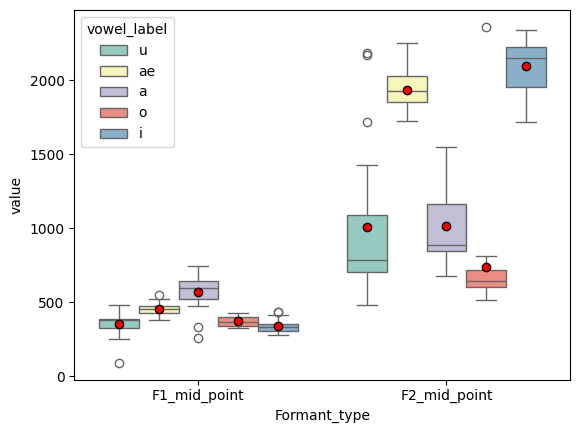

In [22]:
sns.boxplot(x='Formant_type',hue='vowel_label', y='value', data=pd.melt(model_formant_df, id_vars=['participant_id', 'file_id', 'word_label', 'vowel_label', 'gender'], value_vars=['F1_mid_point', 'F2_mid_point'], var_name='Formant_type', col_level=None, ignore_index=True), palette='Set3', showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red'))

<Axes: xlabel='Formant_type', ylabel='value'>

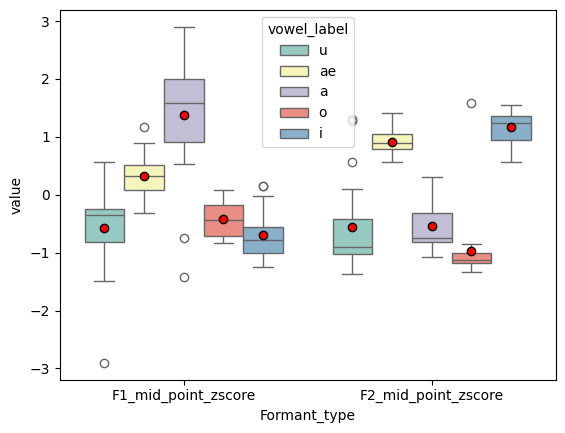

In [23]:
sns.boxplot(x='Formant_type',hue='vowel_label', y='value', data=pd.melt(model_formant_df, id_vars=['participant_id', 'file_id', 'word_label', 'vowel_label', 'gender'], value_vars=['F1_mid_point_zscore', 'F2_mid_point_zscore'], var_name='Formant_type', col_level=None, ignore_index=True), palette='Set3', showmeans=True, meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='red'))

In [77]:
#현재 41584개의 phone, 총 41600개의 phone이 검출되어야 함.
# updated - 09-13(2025) 총 분석 대상이 49명이므로, 49명 * 50개 단어 * 2개 모음 당 단어 * 8번 반복 단어당 = 39200개의 phone이 검출되어야 함.
participant_formant_df

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
0,44,LY044_stage4_20250509_1516.wav,baedsim,ae,3,3.222500,3.292500,0.070000,F,0.333333,...,3089.005746,4172.437683,4,4227.391271,4227.391271,30.238494,4197.152776,4257.629765,2,ae_3.2225
1,44,LY044_stage4_20250509_1516.wav,baedsim,i,6,3.572500,3.632500,0.060000,F,0.200000,...,4088.391434,4153.604215,2,NaN,NaN,NaN,NaN,NaN,0,i_3.5725
2,44,LY044_stage4_20250509_1516.wav,saeljjug,ae,10,5.042500,5.122500,0.080000,F,0.384615,...,4184.583936,4285.566993,5,NaN,NaN,NaN,NaN,NaN,0,ae_5.0425
3,44,LY044_stage4_20250509_1516.wav,saeljjug,u,13,5.422500,5.472500,0.050000,F,0.125000,...,3642.628288,3642.628288,1,4761.590994,4761.590994,0.000000,4761.590994,4761.590994,1,u_5.4225
4,44,LY044_stage4_20250509_1516.wav,pagun,a,17,6.732500,6.792500,0.060000,F,0.200000,...,4229.989416,4293.996870,2,NaN,NaN,NaN,NaN,NaN,0,a_6.7325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39195,31,31_stage5_20250411_1629.wav,noggag,a,912,235.452500,235.512385,0.059885,M,0.200000,...,3200.335809,3229.540645,2,3975.846669,3975.846669,46.274102,3929.572568,4022.120771,2,a_235.4525
39196,31,31_stage5_20250411_1629.wav,sojo,o,916,236.772624,236.842500,0.069876,M,0.333333,...,3165.521738,3198.852584,4,3852.320128,3873.020324,62.309485,3753.105532,3910.134333,4,o_236.7726
39197,31,31_stage5_20250411_1629.wav,sojo,o,918,236.932500,237.102196,0.169696,M,0.714286,...,3129.351938,3341.091963,20,4135.862245,4143.060474,73.706309,3960.563752,4286.350093,20,o_236.9325
39198,31,31_stage5_20250411_1629.wav,milsa,i,921,238.238044,238.317386,0.079341,M,0.384615,...,2924.015808,3001.321744,5,3684.459828,3688.928262,29.280946,3631.227237,3720.754782,5,i_238.2380


In [ ]:
# 이 시점에서는 lobanov norm 잘 되어 있음.
participant_formant_df.columns

Index(['participant_id', 'file_id', 'word_label', 'vowel_label',
       'interval_number', 'start_time', 'end_time', 'duration', 'gender',
       'success_rate', 'mid_point_time', 'F1_mid_point', 'F2_mid_point',
       'F3_mid_point', 'F4_mid_point', 'F5_mid_point', 'F1_mid_point_zscore',
       'F2_mid_point_zscore', 'F1_mean', 'F1_median', 'F1_std', 'F1_min',
       'F1_max', 'F1_count', 'F2_mean', 'F2_median', 'F2_std', 'F2_min',
       'F2_max', 'F2_count', 'F3_mean', 'F3_median', 'F3_std', 'F3_min',
       'F3_max', 'F3_count', 'F4_mean', 'F4_median', 'F4_std', 'F4_min',
       'F4_max', 'F4_count', 'F5_mean', 'F5_median', 'F5_std', 'F5_min',
       'F5_max', 'F5_count', 'interval_key'],
      dtype='object')

체크해야 할 것.
1. 개인 내애서 5종류의 phones, 개당 160회 검출되었는지
2. 개수가 맞다고 해도 단어별 모음 개수 카운팅이 제대로 되었는지 체크 필요.
3. 이상한 단어들이 있는지

## Missing Count

In [ ]:
# 참가자 별로 봤을 때에는 25번이 16개의 phone 누락.
pd.DataFrame(participant_formant_df['participant_id'].value_counts().reset_index().sort_values(by='participant_id', ascending=True)).reset_index().drop(columns=['index'])

,participant_id,count
0,2,800
1,4,800
2,5,800
3,6,800
4,7,800
5,8,800
6,9,800
7,10,800
8,11,800
9,13,800


In [76]:
# 최종적으로 정리.
# 실험 52명 중 데이터가 누수되어 버려진 건 2명(25, 58) / 25번은 여러 단어들이 누락. 58번은 중간에 필생? 을 성골? 이렇게 발음해버림,,
# 따라서 
excepted_p_id = [25, 58]
# 재 검토가 필요한 분절 파일들은 
# 11, 22, 26, 42, 45, 48, 50, 51, 52, 53, 54, 55, 61 인데 대부분 boundary fixation 문제. 
#waiting_list = [11, 22, 26, 42, 45, 48, 50, 51, 52, 53, 54, 55, 61]
#len(excepted_p_id) + len(waiting_list)

In [26]:
# 41600 / 50 = 832개 아닌 것들을 추출.
# 400 / 50 = 800개 아닌 것들을 추출.(25-09-12)
# 26번의 경우 누락된 단어들이 많아서, 
temp = participant_formant_df[['word_label', 'vowel_label']].groupby(['word_label']).count().reset_index()
temp = temp[temp['vowel_label'] != 800].reset_index().drop(columns=['index'])
temp.to_excel(os.path.join(analysis_dir, 'participant_word_mis-aligned.xlsx'))
temp

,word_label,vowel_label


In [127]:
# 단어, 모음 레이블링 잘 됨.
participant_formant_df['word_label'].nunique(), participant_formant_df['vowel_label'].nunique()

(50, 5)

In [101]:
participant_formant_df[participant_formant_df['word_label'] == "sua"]#.to_excel(os.path.join(exp_data_dir, 'participant_formant_df_word_mis-aligned_maengo.xlsx'))

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
414,44,LY044_stage6_20250509_1525.wav,sua,u,45,11.292500,11.432500,0.140000,F,0.652174,...,3760.837363,3943.244015,15,NaN,NaN,NaN,NaN,NaN,0,u_11.2925
415,44,LY044_stage6_20250509_1525.wav,sua,a,46,11.432500,11.732500,0.300000,F,0.836735,...,3047.031228,4923.042775,41,4632.912687,4568.511542,118.803833,4530.722428,4799.504090,3,a_11.4325
10968,34,034_stage4_20250416_1459.wav,sua,u,212,55.303902,55.399435,0.095533,M,0.500000,...,3296.957946,3346.991220,8,3939.802089,3944.037173,14.008568,3911.023920,3959.029614,8,u_55.3039
10969,34,034_stage4_20250416_1459.wav,sua,a,213,55.399435,55.610169,0.210734,M,0.764706,...,3460.024020,3817.341832,26,4058.024609,4055.510314,115.422857,3793.955080,4241.732199,25,a_55.3994


In [78]:
participant_formant_df[(participant_formant_df['participant_id'] == 4) & (participant_formant_df['word_label'] == 'suha')]

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
16899,4,LY04_stage4_20250407_1535.wav,suha,u,306,96.544740,96.638871,0.094132,F,0.500000,...,3686.741384,3846.187047,8,4721.375367,4701.891379,84.271833,4629.294507,4832.940214,3,u_96.5447
16900,4,LY04_stage4_20250407_1535.wav,suha,a,308,96.731929,96.962476,0.230547,F,0.783784,...,3936.065808,4148.750677,29,4248.087285,4101.991983,268.014618,4076.493797,4711.871377,4,a_96.7319
17059,4,LY04_stage4_20250407_1535.wav,suha,u,792,228.176688,228.213301,0.036613,F,0.166667,...,3593.742004,3593.742004,1,4375.303442,4375.303442,0.000000,4375.303442,4375.303442,1,u_228.1767
17060,4,LY04_stage4_20250407_1535.wav,suha,a,794,228.371956,228.562648,0.190692,F,0.741935,...,3988.380377,4199.103960,23,NaN,NaN,NaN,NaN,NaN,0,a_228.3720
17104,4,LY04_stage6_20250407_1544.wav,suha,u,3,2.412500,2.608914,0.196414,F,0.750000,...,3574.082543,3935.405927,24,4507.401801,4554.896194,88.789792,4340.699536,4666.344325,20,u_2.4125
17105,4,LY04_stage6_20250407_1544.wav,suha,a,5,2.703497,2.946058,0.242560,F,0.794872,...,3063.061875,4081.473639,31,4096.355022,4083.269906,49.028019,4054.872882,4241.984351,25,a_2.7035
17300,4,LY04_stage2_20250407_1533.wav,suha,u,300,83.842500,84.000280,0.157780,F,0.692308,...,3643.047770,3979.028325,18,4656.060263,4664.415251,59.067286,4553.724294,4752.401041,12,u_83.8425
17301,4,LY04_stage2_20250407_1533.wav,suha,a,302,84.118509,84.313015,0.194506,F,0.750000,...,3943.361275,4199.213354,24,NaN,NaN,NaN,NaN,NaN,0,a_84.1185
17358,4,LY04_stage5_20250407_1540.wav,suha,u,168,51.905209,52.033277,0.128067,F,0.619048,...,3415.872851,3974.279048,13,4319.843317,4311.181565,131.405713,4160.794119,4585.452286,10,u_51.9052
17359,4,LY04_stage5_20250407_1540.wav,suha,a,170,52.096574,52.342500,0.245926,F,0.800000,...,2985.595781,4282.498157,32,4195.295353,4181.482601,71.317145,4117.470972,4400.942166,19,a_52.0966


In [118]:
# 2, 4, 9, 11, 19, 25
temp = participant_formant_df[['participant_id', 'word_label', 'vowel_label']].groupby(['participant_id', 'vowel_label']).count().reset_index()
temp[temp['word_label'] != 160].reset_index().drop(columns=['index'])

,participant_id,vowel_label,word_label
0,25,a,158
1,25,ae,158
2,25,i,158
3,25,o,155
4,25,u,155


In [ ]:
# 25 번만 문제
temp = participant_formant_df[['participant_id', 'word_label', 'vowel_label']].groupby(['participant_id', 'word_label']).count().reset_index()
temp[temp['vowel_label'] != 16]
#temp

,participant_id,word_label,vowel_label
910,25,maebog,14
919,25,muun,14
930,25,paemul,14
935,25,pipog,14
936,25,pogab,14
944,25,siljog,14
947,25,songbu,14
948,25,suha,14


In [56]:
participant_formant_df[(participant_formant_df['participant_id'] == 2) & (participant_formant_df['word_label'] == 'suaha')]

,participant_id,file_id,word_label,vowel_label,interval_number,start_time,end_time,duration,gender,success_rate,...,F4_min,F4_max,F4_count,F5_mean,F5_median,F5_std,F5_min,F5_max,F5_count,interval_key
12837,2,02_stage6_20250404_1401.wav,suaha,u,121,22.231461,22.316473,0.085011,F,0.428571,...,3635.741897,3732.698840,6,4705.871120,4703.446517,49.735179,4647.646348,4792.493442,5,u_22.2315
12838,2,02_stage6_20250404_1401.wav,suaha,a,122,22.316473,22.317485,0.001012,F,1.000000,...,4096.802179,4096.802179,1,NaN,NaN,NaN,NaN,NaN,0,a_22.3165
12839,2,02_stage6_20250404_1401.wav,suaha,a,124,22.344810,22.520905,0.176095,F,0.724138,...,3859.085580,4172.425233,21,4538.838458,4538.838458,0.000000,4538.838458,4538.838458,1,a_22.3448
13034,2,02_stage5_20250404_1357.wav,suaha,u,108,33.275101,33.354429,0.079328,F,0.384615,...,3596.476173,3665.788215,5,4665.647714,4673.734904,48.468900,4599.213469,4723.610436,5,u_33.2751
13035,2,02_stage5_20250404_1357.wav,suaha,a,109,33.354429,33.357480,0.003051,F,1.000000,...,3690.232026,3690.232026,1,NaN,NaN,NaN,NaN,NaN,0,a_33.3544
13036,2,02_stage5_20250404_1357.wav,suaha,a,111,33.404772,33.592413,0.187641,F,0.741935,...,3789.856272,3886.031504,23,4792.185255,4798.249915,48.207498,4705.610668,4852.925237,5,a_33.4048


In [ ]:
#participant_formant_df.groupby(['participant_id', 'word_label', 'vowel_label']).count().reset_index()[['participant_id', 'word_label', 'vowel_label', 'file_id']].to_excel(os.path.join(exp_data_dir, 'participant_formant_df_word_count.xlsx'))

In [53]:
participant_formant_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38388 entries, 0 to 38387
Data columns (total 41 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   participant_id   38388 non-null  int64  
 1   file_id          38388 non-null  object 
 2   word_label       38388 non-null  object 
 3   vowel_label      38388 non-null  object 
 4   interval_number  38388 non-null  int64  
 5   start_time       38388 non-null  float64
 6   end_time         38388 non-null  float64
 7   duration         38388 non-null  float64
 8   gender           38388 non-null  object 
 9   success_rate     38388 non-null  float64
 10  F1_mean          38387 non-null  float64
 11  F1_median        38387 non-null  float64
 12  F1_std           38387 non-null  float64
 13  F1_min           38387 non-null  float64
 14  F1_max           38387 non-null  float64
 15  F1_count         38388 non-null  int64  
 16  F2_mean          38387 non-null  float64
 17  F2_median   

In [21]:
participant_formant_df.columns

Index(['participant_id', 'file_id', 'word_label', 'vowel_label',
       'interval_number', 'start_time', 'end_time', 'duration', 'gender',
       'success_rate', 'mid_point_time', 'F1_mid_point', 'F2_mid_point',
       'F3_mid_point', 'F4_mid_point', 'F5_mid_point', 'F1_mean', 'F1_median',
       'F1_std', 'F1_min', 'F1_max', 'F1_count', 'F2_mean', 'F2_median',
       'F2_std', 'F2_min', 'F2_max', 'F2_count', 'F3_mean', 'F3_median',
       'F3_std', 'F3_min', 'F3_max', 'F3_count', 'F4_mean', 'F4_median',
       'F4_std', 'F4_min', 'F4_max', 'F4_count', 'F5_mean', 'F5_median',
       'F5_std', 'F5_min', 'F5_max', 'F5_count', 'interval_key'],
      dtype='object')

## 여기부터 analysis

현재 분석 제외대상은 drop

In [80]:
participant_formant_df.columns

Index(['participant_id', 'file_id', 'word_label', 'vowel_label',
       'interval_number', 'start_time', 'end_time', 'duration', 'gender',
       'success_rate', 'mid_point_time', 'F1_mid_point', 'F2_mid_point',
       'F3_mid_point', 'F4_mid_point', 'F5_mid_point', 'F1_mid_point_zscore',
       'F2_mid_point_zscore', 'F1_mean', 'F1_median', 'F1_std', 'F1_min',
       'F1_max', 'F1_count', 'F2_mean', 'F2_median', 'F2_std', 'F2_min',
       'F2_max', 'F2_count', 'F3_mean', 'F3_median', 'F3_std', 'F3_min',
       'F3_max', 'F3_count', 'F4_mean', 'F4_median', 'F4_std', 'F4_min',
       'F4_max', 'F4_count', 'F5_mean', 'F5_median', 'F5_std', 'F5_min',
       'F5_max', 'F5_count', 'interval_key'],
      dtype='object')

In [81]:
#analyzed_p_df = participant_formant_df[~participant_formant_df['participant_id'].isin(excepted_p_id)].reset_index(drop=True)
analyzed_p_df = participant_formant_df.copy()
analyzed_p_df.drop(columns=[
       'interval_number', 'start_time', 'end_time', 'mid_point_time',
       'F1_std', 'F1_min', 'F1_max', 'F1_count', 
       'F2_std', 'F2_min', 'F2_max', 'F2_count', 
       'F3_mean', 'F3_median', 'F3_std', 'F3_min', 'F3_max', 'F3_count', 'F3_mid_point', 
       'F4_mean', 'F4_median', 'F4_std', 'F4_min', 'F4_max', 'F4_count', 'F4_mid_point',
       'F5_mean', 'F5_median', 'F5_std', 'F5_min', 'F5_max', 'F5_count', 'F5_mid_point',
       ], inplace=True)
analyzed_p_df

,participant_id,file_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key
0,44,LY044_stage4_20250509_1516.wav,baedsim,ae,0.070000,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225
1,44,LY044_stage4_20250509_1516.wav,baedsim,i,0.060000,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725
2,44,LY044_stage4_20250509_1516.wav,saeljjug,ae,0.080000,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425
3,44,LY044_stage4_20250509_1516.wav,saeljjug,u,0.050000,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225
4,44,LY044_stage4_20250509_1516.wav,pagun,a,0.060000,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39195,31,31_stage5_20250411_1629.wav,noggag,a,0.059885,M,0.200000,726.250484,1168.585673,1.581064,-0.454072,723.700132,723.700132,1170.136887,1170.136887,a_235.4525
39196,31,31_stage5_20250411_1629.wav,sojo,o,0.069876,M,0.333333,420.897669,962.289635,-0.600491,-0.891842,418.956103,420.482805,968.555184,959.179292,o_236.7726
39197,31,31_stage5_20250411_1629.wav,sojo,o,0.169696,M,0.714286,441.347217,759.241196,-0.454392,-1.322721,454.139839,450.653150,809.972842,768.095206,o_236.9325
39198,31,31_stage5_20250411_1629.wav,milsa,i,0.079341,M,0.384615,333.155027,1703.899176,-1.227357,0.681888,333.142924,330.639481,1711.616584,1710.708575,i_238.2380


In [32]:
analyzed_p_df.columns

Index(['participant_id', 'file_id', 'word_label', 'vowel_label', 'duration',
       'gender', 'success_rate', 'F1_mid_point', 'F2_mid_point',
       'F1_mid_point_zscore', 'F2_mid_point_zscore', 'F1_mean', 'F1_median',
       'F2_mean', 'F2_median', 'interval_key'],
      dtype='object')

In [82]:
analyzed_p_df['stage'] = analyzed_p_df['file_id'].str.split('_').str[1]
analyzed_p_df

,participant_id,file_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key,stage
0,44,LY044_stage4_20250509_1516.wav,baedsim,ae,0.070000,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225,stage4
1,44,LY044_stage4_20250509_1516.wav,baedsim,i,0.060000,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725,stage4
2,44,LY044_stage4_20250509_1516.wav,saeljjug,ae,0.080000,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425,stage4
3,44,LY044_stage4_20250509_1516.wav,saeljjug,u,0.050000,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225,stage4
4,44,LY044_stage4_20250509_1516.wav,pagun,a,0.060000,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325,stage4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39195,31,31_stage5_20250411_1629.wav,noggag,a,0.059885,M,0.200000,726.250484,1168.585673,1.581064,-0.454072,723.700132,723.700132,1170.136887,1170.136887,a_235.4525,stage5
39196,31,31_stage5_20250411_1629.wav,sojo,o,0.069876,M,0.333333,420.897669,962.289635,-0.600491,-0.891842,418.956103,420.482805,968.555184,959.179292,o_236.7726,stage5
39197,31,31_stage5_20250411_1629.wav,sojo,o,0.169696,M,0.714286,441.347217,759.241196,-0.454392,-1.322721,454.139839,450.653150,809.972842,768.095206,o_236.9325,stage5
39198,31,31_stage5_20250411_1629.wav,milsa,i,0.079341,M,0.384615,333.155027,1703.899176,-1.227357,0.681888,333.142924,330.639481,1711.616584,1710.708575,i_238.2380,stage5


In [83]:
analyzed_p_df.drop('file_id', axis=1, inplace=True)

In [86]:
analyzed_p_df

,participant_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key,stage
0,44,baedsim,ae,0.070000,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225,stage4
1,44,baedsim,i,0.060000,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725,stage4
2,44,saeljjug,ae,0.080000,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425,stage4
3,44,saeljjug,u,0.050000,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225,stage4
4,44,pagun,a,0.060000,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325,stage4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39195,31,noggag,a,0.059885,M,0.200000,726.250484,1168.585673,1.581064,-0.454072,723.700132,723.700132,1170.136887,1170.136887,a_235.4525,stage5
39196,31,sojo,o,0.069876,M,0.333333,420.897669,962.289635,-0.600491,-0.891842,418.956103,420.482805,968.555184,959.179292,o_236.7726,stage5
39197,31,sojo,o,0.169696,M,0.714286,441.347217,759.241196,-0.454392,-1.322721,454.139839,450.653150,809.972842,768.095206,o_236.9325,stage5
39198,31,milsa,i,0.079341,M,0.384615,333.155027,1703.899176,-1.227357,0.681888,333.142924,330.639481,1711.616584,1710.708575,i_238.2380,stage5


In [60]:
# 1단계: F1_mid_point_zscore을 groupby로 계산하고 DataFrame으로 변환
f1_z_df = analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F1_mid_point_zscore'].mean().reset_index()
f1_df = analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F1_mid_point'].mean().reset_index()

# 2단계: F2_mid_point_zscore을 groupby로 계산하고 DataFrame으로 변환  
f2_z_df = analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F2_mid_point_zscore'].mean().reset_index()
f2_df = analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['F2_mid_point'].mean().reset_index()

# duration
duration_df = analyzed_p_df.groupby(['participant_id', 'vowel_label', 'stage'])['duration'].mean().reset_index()

# 3단계: 두 DataFrame을 merge
p_z_formant_stage_df = pd.merge(f1_z_df, f2_z_df, on=['participant_id', 'vowel_label', 'stage'], how='inner')
p_formant_stage_df = pd.merge(f1_df, f2_df, on=['participant_id', 'vowel_label', 'stage'], how='inner')
p_formant_stage_df = pd.merge(p_formant_stage_df, p_z_formant_stage_df, on=['participant_id', 'vowel_label', 'stage'], how='inner')
p_formant_stage_df = pd.merge(p_formant_stage_df, duration_df, on=['participant_id', 'vowel_label', 'stage'], how='inner')


p_formant_stage_df.reset_index().drop(columns=['index'], inplace=True)
p_formant_stage_df.to_excel(os.path.join(analysis_dir, 'formant_results_all_vowels_participant_stage_zscore.xlsx'), index=False)
p_formant_stage_df



,participant_id,vowel_label,stage,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,duration
0,2,a,stage2,836.554487,1473.913084,1.891237,-0.251917,0.104880
1,2,a,stage4,819.642832,1421.081586,1.790754,-0.339473,0.112814
2,2,a,stage5,803.486769,1387.071394,1.694760,-0.395837,0.113312
3,2,a,stage6,833.521656,1413.804175,1.873217,-0.351534,0.092202
4,2,ae,stage2,547.556313,2195.762765,0.174113,0.944388,0.110337
...,...,...,...,...,...,...,...,...
975,62,o,stage6,363.378406,808.035333,-0.440525,-1.242784,0.123704
976,62,u,stage2,389.569875,1101.965479,-0.290992,-0.752709,0.144763
977,62,u,stage4,420.578543,1306.452483,-0.113957,-0.411763,0.099395
978,62,u,stage5,406.060532,1246.095028,-0.196843,-0.512399,0.097237


In [61]:
model_formant_standard_df.reset_index().drop(columns=['index'], inplace=True)

In [67]:
model_formant_standard_df

,vowel_label,F1_mid_mean,F2_mid_mean,F1_mid_mean(z),F2_mid_mean(z),duration
0,a,573.250874,1018.915275,1.369334,-0.535361,0.102032
1,ae,454.973640,1935.437596,0.319214,0.906597,0.128425
2,i,340.850616,2098.134697,-0.694023,1.162567,0.115465
3,o,371.226331,737.733796,-0.424334,-0.977741,0.098706
4,u,354.798083,1005.757280,-0.570191,-0.556062,0.083858


In [68]:
model_formant_standard_df.to_excel(os.path.join(analysis_dir, 'formant_results_all_vowels_model_standard.xlsx'), index=False)

# Convergence Test

In [ ]:
participant_list_df = pd.DataFrame(
    {'1. 참가자 번호' : [p.split('_')[1] for p in participant_list]
    }
)

In [145]:
survey_path = os.path.join(exp_data_dir, 'survey-latest.xlsx')
pd.read_excel(survey_path).head()

,타임스탬프,1. 참가자 번호,"2. (2, 3 단계)에서 들으신 발음을 한 주체는 누구입니까?","3. (2, 3단계)에서 들으신 발음을 듣고 어떠한 인상이 느껴지셨습니까?","4. (2, 3단계)에서 들으신 발음을 듣고 어떠한 인상이 느껴지셨습니까?",Actual_list_Num,mismatched_humanness,Gender,analysis_flag
0,2025-04-01 17:22:50.551,LY003,AI,1.0,NaN,1,NaN,M,0
1,2025-04-02 14:22:27.390,LY016,사람,2.0,3.0,2,NaN,M,0
2,2025-04-02 15:28:16.671,LY012,AI,2.0,NaN,1,NaN,F,0
3,2025-04-02 19:14:42.044,LY001,사람,2.0,7.0,1,V,M,0
4,2025-04-03 13:32:17.720,LY014,사람,NaN,7.0,2,NaN,M,0


In [150]:
model_formant_standard_df = pd.read_excel(os.path.join(analysis_dir, 'formant_results_all_vowels_model_standard.xlsx'))
model_formant_standard_df

,vowel_label,F1_mid_mean,F2_mid_mean,F1_mid_mean(z),F2_mid_mean(z),duration
0,a,573.250874,1018.915275,1.369334,-0.535361,0.102032
1,ae,454.973640,1935.437596,0.319214,0.906597,0.128425
2,i,340.850616,2098.134697,-0.694023,1.162567,0.115465
3,o,371.226331,737.733796,-0.424334,-0.977741,0.098706
4,u,354.798083,1005.757280,-0.570191,-0.556062,0.083858


In [151]:
p_info = pd.merge(pd.read_excel(survey_path), participant_list_df, on='1. 참가자 번호', how='inner')

In [74]:
p_info[['1. 참가자 번호', 'Gender', 'Actual_list_Num']].groupby(['Actual_list_Num', 'Gender']).count().reset_index()
#.sort_values(by='1. 참가자 번호', ascending=True)

,Actual_list_Num,Gender,1. 참가자 번호
0,1.0,F,12
1,1.0,M,13
2,2.0,F,13
3,2.0,M,11


In [ ]:
participant_freq_df = pd.read_excel(os.path.join(analysis_dir, 'formant_results_all_vowels_participant_stage.xlsx'))
participant_freq_zscore_df = pd.read_excel(os.path.join(analysis_dir, 'formant_results_all_vowels_participant_stage_zscore.xlsx'))

In [76]:
#participant_freq_zscore_df = participant_freq_zscore_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])
participant_freq_zscore_df

,participant_id,vowel_label,stage,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,duration
0,2,a,stage2,836.554487,1473.913084,1.891237,-0.251917,0.104880
1,2,a,stage4,819.642832,1421.081586,1.790754,-0.339473,0.112814
2,2,a,stage5,803.486769,1387.071394,1.694760,-0.395837,0.113312
3,2,a,stage6,833.521656,1413.804175,1.873217,-0.351534,0.092202
4,2,ae,stage2,547.556313,2195.762765,0.174113,0.944388,0.110337
...,...,...,...,...,...,...,...,...
975,62,o,stage6,363.378406,808.035333,-0.440525,-1.242784,0.123704
976,62,u,stage2,389.569875,1101.965479,-0.290992,-0.752709,0.144763
977,62,u,stage4,420.578543,1306.452483,-0.113957,-0.411763,0.099395
978,62,u,stage5,406.060532,1246.095028,-0.196843,-0.512399,0.097237


## Info merging

In [ ]:
p_info.head()

,타임스탬프,1. 참가자 번호,"2. (2, 3 단계)에서 들으신 발음을 한 주체는 누구입니까?","3. (2, 3단계)에서 들으신 발음을 듣고 어떠한 인상이 느껴지셨습니까?","4. (2, 3단계)에서 들으신 발음을 듣고 어떠한 인상이 느껴지셨습니까?",Actual_list_Num,mismatched_humanness,Gender,analysis_flag,Data-viewing,Comment
0,2025-04-03 15:07:08.523,LY019,AI,6.0,4.0,1.0,NaN,M,1.0,NaN,여기부터 분석. 위는 pilot. 아래와는 실험 자극이 다름
1,2025-04-03 18:24:22.639,LY011,사람,5.0,5.0,2.0,NaN,F,1.0,NaN,NaN
2,2025-04-03 19:58:42.765,LY007,AI,3.0,5.0,1.0,NaN,M,1.0,NaN,NaN
3,2025-04-04 11:27:51.271,LY022,사람,1.0,6.0,2.0,NaN,F,1.0,NaN,NaN
4,2025-04-04 14:03:22.407,LY002,AI,2.0,6.0,1.0,NaN,F,1.0,NaN,NaN


In [90]:
p_info['participant_id'] = p_info['1. 참가자 번호'].str.replace('LY', '').astype(int)
p_info.head()

,타임스탬프,1. 참가자 번호,"2. (2, 3 단계)에서 들으신 발음을 한 주체는 누구입니까?","3. (2, 3단계)에서 들으신 발음을 듣고 어떠한 인상이 느껴지셨습니까?","4. (2, 3단계)에서 들으신 발음을 듣고 어떠한 인상이 느껴지셨습니까?",Actual_list_Num,mismatched_humanness,Gender,analysis_flag,Data-viewing,Comment,participant_id
0,2025-04-03 15:07:08.523,LY019,AI,6.0,4.0,1.0,NaN,M,1.0,NaN,여기부터 분석. 위는 pilot. 아래와는 실험 자극이 다름,19
1,2025-04-03 18:24:22.639,LY011,사람,5.0,5.0,2.0,NaN,F,1.0,NaN,NaN,11
2,2025-04-03 19:58:42.765,LY007,AI,3.0,5.0,1.0,NaN,M,1.0,NaN,NaN,7
3,2025-04-04 11:27:51.271,LY022,사람,1.0,6.0,2.0,NaN,F,1.0,NaN,NaN,22
4,2025-04-04 14:03:22.407,LY002,AI,2.0,6.0,1.0,NaN,F,1.0,NaN,NaN,2


In [95]:
gender = []
actual_list = []
for idx, item in participant_freq_zscore_df.iterrows():
    participant_id = item.__getitem__('participant_id')
    print(f"participant_id: {participant_id}")

    target_df = p_info[p_info['participant_id'] == participant_id]

    if target_df.empty:
        print(f"participant_id: {participant_id} is not in p_info")
        continue
    elif len(target_df) > 1:
        print(f"participant_id: {participant_id} is not not exactly matched")
        continue
    
    gender.append(target_df['Gender'].values[0])
    actual_list.append('AI' if target_df['Actual_list_Num'].values[0] == 1 else 'Human')
    print(f"participant_id: {participant_id}, gender: {gender[-1]}, actual_list: {actual_list[-1]}")

participant_freq_zscore_df['gender'] = gender
participant_freq_zscore_df['actual_list'] = actual_list
participant_freq_zscore_df.head()

participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gender: F, actual_list: AI
participant_id: 2
participant_id: 2, gen

,participant_id,vowel_label,stage,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,duration,gender,actual_list
0,2,a,stage2,836.554487,1473.913084,1.891237,-0.251917,0.104880,F,AI
1,2,a,stage4,819.642832,1421.081586,1.790754,-0.339473,0.112814,F,AI
2,2,a,stage5,803.486769,1387.071394,1.694760,-0.395837,0.113312,F,AI
3,2,a,stage6,833.521656,1413.804175,1.873217,-0.351534,0.092202,F,AI
4,2,ae,stage2,547.556313,2195.762765,0.174113,0.944388,0.110337,F,AI


## Metric Define

전체적인 흐름은 stage 별로 metric을 적용하여 stage별 변화를 보자!

DID

$$dist = \sqrt{(f1_{participant} - f1_{model})^2 + (f2_{participant} - f2_{model})^2}$$

아래 2개의 df를 합쳐서 regression 돌릴거임.

In [ ]:
analyzed_p_df.loc[0, 'F1_mid_point_zscore']

np.float64(-0.7563969395879426)

In [ ]:
# vowel 수준까진 normed 되지 않음. -> correct!
analyzed_p_df[(analyzed_p_df['participant_id'] == 44) & (analyzed_p_df['vowel_label'] == 'a')].describe()

,participant_id,duration,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median
count,160.0,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,44.0,0.130108,0.543882,879.440541,1480.926727,1.532554,-0.264786,877.321929,885.106252,1489.795086,1498.121552
std,0.0,0.067619,0.198260,163.345014,236.466823,0.755412,0.435230,129.850251,142.478311,189.164755,195.593892
min,44.0,0.030000,0.125000,249.276890,595.531920,-1.381725,-1.894403,386.663841,359.327917,595.531920,595.531920
25%,44.0,0.080000,0.384615,857.234741,1392.126604,1.429861,-0.428227,847.318600,860.484552,1406.146271,1409.413761
50%,44.0,0.110000,0.562500,927.635805,1489.517805,1.755440,-0.248973,903.601187,924.886021,1478.448682,1486.356593
75%,44.0,0.180000,0.724138,976.800532,1580.100797,1.982809,-0.082251,964.632181,970.195834,1562.361163,1580.375099
max,44.0,0.380000,0.868852,1173.861608,2191.693165,2.894146,1.043418,1129.644530,1125.560673,2046.854615,2094.670487


In [101]:
model_formant_df.columns

Index(['participant_id', 'file_id', 'word_label', 'vowel_label',
       'interval_number', 'start_time', 'end_time', 'duration', 'gender',
       'success_rate', 'mid_point_time', 'F1_mid_point', 'F2_mid_point',
       'F3_mid_point', 'F4_mid_point', 'F5_mid_point', 'F1_mid_point_zscore',
       'F2_mid_point_zscore', 'F1_mean', 'F1_median', 'F1_std', 'F1_min',
       'F1_max', 'F1_count', 'F2_mean', 'F2_median', 'F2_std', 'F2_min',
       'F2_max', 'F2_count', 'F3_mean', 'F3_median', 'F3_std', 'F3_min',
       'F3_max', 'F3_count', 'F4_mean', 'F4_median', 'F4_std', 'F4_min',
       'F4_max', 'F4_count', 'F5_mean', 'F5_median', 'F5_std', 'F5_min',
       'F5_max', 'F5_count', 'interval_key'],
      dtype='object')

In [126]:
dist = []
dist_z = []
for idx, item in analyzed_p_df.iterrows():
    vowel_label = item.__getitem__('vowel_label')
    word_label = item.__getitem__('word_label')
    #participant_id, vowel_label, stage, F1_mid_point, F2_mid_point, F1_mid_point_zscore, F2_mid_point_zscore = item
    vowel_mask = model_formant_df['vowel_label'] == vowel_label
    word_mask = model_formant_df['word_label'] == word_label.upper() # char 대소문자 통일.

    diff_f1_z = (analyzed_p_df.loc[idx, 'F1_mid_point_zscore'] - model_formant_df[vowel_mask & word_mask]['F1_mid_point_zscore']).values[0]
    diff_f2_z = (analyzed_p_df.loc[idx, 'F2_mid_point_zscore'] - model_formant_df[word_mask & vowel_mask]['F2_mid_point_zscore']).values[0]
    diff_f1 = (analyzed_p_df.loc[idx, 'F1_mid_point'] - model_formant_df[vowel_mask & word_mask]['F1_mid_point']).values[0]
    diff_f2 = (analyzed_p_df.loc[idx, 'F2_mid_point'] - model_formant_df[word_mask & vowel_mask]['F2_mid_point']).values[0]
    
    dist_z.append(np.sqrt(diff_f1_z**2 + diff_f2_z**2))
    dist.append(np.sqrt(diff_f1**2 + diff_f2**2))
    #print(f"vowel_label: {vowel_label}, dist_z: {dist_z[-1]}, dist: {dist[-1]}")

analyzed_p_df['dist(z)'] = dist_z
analyzed_p_df['dist'] = dist
analyzed_p_df

,participant_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key,stage,dist(z),dist
0,44,baedsim,ae,0.070000,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225,stage4,1.467817,409.557644
1,44,baedsim,i,0.060000,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725,stage4,0.860147,514.306725
2,44,saeljjug,ae,0.080000,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425,stage4,1.421120,486.499923
3,44,saeljjug,u,0.050000,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225,stage4,0.599498,691.159827
4,44,pagun,a,0.060000,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325,stage4,0.911789,741.700523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39195,31,noggag,a,0.059885,M,0.200000,726.250484,1168.585673,1.581064,-0.454072,723.700132,723.700132,1170.136887,1170.136887,a_235.4525,stage5,0.322997,290.277170
39196,31,sojo,o,0.069876,M,0.333333,420.897669,962.289635,-0.600491,-0.891842,418.956103,420.482805,968.555184,959.179292,o_236.7726,stage5,0.244625,245.765846
39197,31,sojo,o,0.169696,M,0.714286,441.347217,759.241196,-0.454392,-1.322721,454.139839,450.653150,809.972842,768.095206,o_236.9325,stage5,0.506587,117.994264
39198,31,milsa,i,0.079341,M,0.384615,333.155027,1703.899176,-1.227357,0.681888,333.142924,330.639481,1711.616584,1710.708575,i_238.2380,stage5,0.291855,195.980109


In [133]:
dist_vl = []
for idx, item in analyzed_p_df.iterrows():
    vowel_label = item.__getitem__('vowel_label')
    word_label = item.__getitem__('word_label')
    duration = item.__getitem__('duration')

    #participant_id, vowel_label, stage, F1_mid_point, F2_mid_point, F1_mid_point_zscore, F2_mid_point_zscore = item
    # vowel length: duration
    word_mask = model_formant_df['word_label'] == word_label.upper()
    vowel_mask = model_formant_df['vowel_label'] == vowel_label
    dist_vl.append((duration - model_formant_df[word_mask & vowel_mask]['duration']).values[0])
    
    
analyzed_p_df['dist_vl'] = dist_vl
analyzed_p_df.head()

,participant_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key,stage,dist(z),dist,dist_vl
0,44,baedsim,ae,0.07,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225,stage4,1.467817,409.557644,-3.092253e-03
1,44,baedsim,i,0.06,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725,stage4,0.860147,514.306725,-3.000000e-02
2,44,saeljjug,ae,0.08,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425,stage4,1.421120,486.499923,2.729352e-02
3,44,saeljjug,u,0.05,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225,stage4,0.599498,691.159827,-2.151057e-16
4,44,pagun,a,0.06,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325,stage4,0.911789,741.700523,2.000000e-02


In [135]:
analyzed_p_df.to_excel(os.path.join(analysis_dir, 'participant_analysis_full(vowel)-1104.xlsx'), index=False)

In [134]:
participant_freq_zscore_df.to_excel(os.path.join(analysis_dir, 'participant_analysis_full(vowel).xlsx'), index=False)

NameError: name 'participant_freq_zscore_df' is not defined

# Analysis

## 통계 분석: ANOVA 및 t-test

이 섹션에서는 다음 분석을 수행합니다:
1. list, stage별로 dist metric에 유의미한 차이가 있는지 ANOVA 분석
2. 성별에 의한 차이 분석 (t-test)


In [136]:
# 통계 분석을 위한 추가 라이브러리 import
from scipy import stats
from scipy.stats import f_oneway, ttest_ind
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.formula.api as smf
import warnings
import os
import pandas as pd
from matplotlib import pyplot as plt
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [137]:
analysis_df = pd.read_excel(os.path.join(analysis_dir, 'participant_analysis_full(vowel)-1104.xlsx'))
analysis_df.head()

,participant_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key,stage,dist(z),dist,dist_vl
0,44,baedsim,ae,0.07,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225,stage4,1.467817,409.557644,-3.092253e-03
1,44,baedsim,i,0.06,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725,stage4,0.860147,514.306725,-3.000000e-02
2,44,saeljjug,ae,0.08,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425,stage4,1.421120,486.499923,2.729352e-02
3,44,saeljjug,u,0.05,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225,stage4,0.599498,691.159827,-2.151057e-16
4,44,pagun,a,0.06,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325,stage4,0.911789,741.700523,2.000000e-02


### make DID cell(difference in Distance)

In [138]:
DID_z = []
#DID_dist = []
for idx, item in analysis_df.iterrows():
    id_mask = analysis_df['participant_id'] == item['participant_id']
    vowel_mask = analysis_df['vowel_label'] == item['vowel_label']
    stage_mask = analysis_df['stage'] != 'stage2'
    
    # append the DID
    DID_z.append(item['dist(z)'] - analysis_df[id_mask & vowel_mask & stage_mask]['dist(z)'].values[0])
    #DID_dist.append(item['dist'] - analysis_df[id_mask & vowel_mask & stage_mask]['dist'].values[0])

analysis_df['DID_z'] = DID_z
#analysis_df['DID_dist'] = DID_dist
analysis_df

,participant_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key,stage,dist(z),dist,dist_vl,DID_z
0,44,baedsim,ae,0.070000,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225,stage4,1.467817,409.557644,-3.092253e-03,0.000000
1,44,baedsim,i,0.060000,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725,stage4,0.860147,514.306725,-3.000000e-02,0.000000
2,44,saeljjug,ae,0.080000,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425,stage4,1.421120,486.499923,2.729352e-02,-0.046697
3,44,saeljjug,u,0.050000,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225,stage4,0.599498,691.159827,-2.151057e-16,0.000000
4,44,pagun,a,0.060000,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325,stage4,0.911789,741.700523,2.000000e-02,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39195,31,noggag,a,0.059885,M,0.200000,726.250484,1168.585673,1.581064,-0.454072,723.700132,723.700132,1170.136887,1170.136887,a_235.4525,stage5,0.322997,290.277170,-1.587990e-02,-0.069624
39196,31,sojo,o,0.069876,M,0.333333,420.897669,962.289635,-0.600491,-0.891842,418.956103,420.482805,968.555184,959.179292,o_236.7726,stage5,0.244625,245.765846,-1.929601e-02,-0.149886
39197,31,sojo,o,0.169696,M,0.714286,441.347217,759.241196,-0.454392,-1.322721,454.139839,450.653150,809.972842,768.095206,o_236.9325,stage5,0.506587,117.994264,8.052458e-02,0.112076
39198,31,milsa,i,0.079341,M,0.384615,333.155027,1703.899176,-1.227357,0.681888,333.142924,330.639481,1711.616584,1710.708575,i_238.2380,stage5,0.291855,195.980109,-4.065865e-02,0.014167


In [139]:
analysis_df.to_excel(os.path.join(analysis_dir, 'participant_analysis_DID-1104.xlsx'), index=False)

In [ ]:
analysis_df = pd.read_excel(os.path.join(analysis_dir, 'participant_analysis_DID-1104.xlsx'))

In [ ]:
# drop baseline
mask_stage2 = (analysis_df['stage'] == 'stage2') #| (analysis_df['stage'] == 'stage4')
analysis_df = analysis_df[~mask_stage2].reset_index(drop=True)
analysis_df


,participant_id,word_label,vowel_label,duration,gender,success_rate,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,F1_mean,F1_median,F2_mean,F2_median,interval_key,stage,dist(z),dist,dist_vl,DID_z
0,44,baedsim,ae,0.070000,F,0.333333,384.493591,1352.325456,-0.756397,-0.501483,480.082065,532.661911,1477.530061,1521.709406,ae_3.2225,stage4,1.467817,409.557644,-3.092253e-03,0.000000
1,44,baedsim,i,0.060000,F,0.200000,400.340258,2232.672835,-0.683112,1.118844,402.216464,402.216464,2249.730218,2249.730218,i_3.5725,stage4,0.860147,514.306725,-3.000000e-02,0.000000
2,44,saeljjug,ae,0.080000,F,0.384615,820.103863,2180.044948,1.258144,1.021979,807.921070,834.780768,2129.038536,2146.166640,ae_5.0425,stage4,1.421120,486.499923,2.729352e-02,-0.046697
3,44,saeljjug,u,0.050000,F,0.125000,452.165926,1332.625004,-0.443437,-0.537743,452.165926,452.165926,1332.625004,1332.625004,u_5.4225,stage4,0.599498,691.159827,-2.151057e-16,0.000000
4,44,pagun,a,0.060000,F,0.200000,954.963715,1529.521017,1.881822,-0.175345,964.472855,964.472855,1530.222699,1530.222699,a_6.7325,stage4,0.911789,741.700523,2.000000e-02,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34295,31,noggag,a,0.059885,M,0.200000,726.250484,1168.585673,1.581064,-0.454072,723.700132,723.700132,1170.136887,1170.136887,a_235.4525,stage5,0.322997,290.277170,-1.587990e-02,-0.069624
34296,31,sojo,o,0.069876,M,0.333333,420.897669,962.289635,-0.600491,-0.891842,418.956103,420.482805,968.555184,959.179292,o_236.7726,stage5,0.244625,245.765846,-1.929601e-02,-0.149886
34297,31,sojo,o,0.169696,M,0.714286,441.347217,759.241196,-0.454392,-1.322721,454.139839,450.653150,809.972842,768.095206,o_236.9325,stage5,0.506587,117.994264,8.052458e-02,0.112076
34298,31,milsa,i,0.079341,M,0.384615,333.155027,1703.899176,-1.227357,0.681888,333.142924,330.639481,1711.616584,1710.708575,i_238.2380,stage5,0.291855,195.980109,-4.065865e-02,0.014167


In [144]:
analysis_df.columns

Index(['participant_id', 'word_label', 'vowel_label', 'duration', 'gender',
       'success_rate', 'F1_mid_point', 'F2_mid_point', 'F1_mid_point_zscore',
       'F2_mid_point_zscore', 'F1_mean', 'F1_median', 'F2_mean', 'F2_median',
       'interval_key', 'stage', 'dist(z)', 'dist', 'dist_vl', 'DID_z'],
      dtype='object')

In [142]:
analysis_df['vowel_label'].nunique()

5

In [143]:
# LMM
formula = 'DID_z ~ C(actual_list) * C(gender)'
model = MixedLM.from_formula(formula,
    data=analysis_df, 
    groups='participant_id',
    re_formula='~ C(stage) + C(vowel_label)').fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
#result = pd.DataFrame(model.summary().tables[1])
#result['reject'] = result['PR(>F)'] < 0.05
#result
model.summary()

PatsyError: Error evaluating factor: NameError: name 'actual_list' is not defined
    DID_z ~ C(actual_list) * C(gender)
            ^^^^^^^^^^^^^^

In [67]:
formula = 'dist_vl ~ C(actual_list) * C(gender)'
model = MixedLM.from_formula(formula,
    data=analysis_df, 
    groups='participant_id',
    re_formula='~ C(stage) + C(vowel_label)').fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
#result = pd.DataFrame(model.summary().tables[1])
#result['reject'] = result['PR(>F)'] < 0.05
#result
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Mixed Linear Model Regression Results
=========================================================================================
Model:                        MixedLM            Dependent Variable:            dist_vl  
No. Observations:             735                Method:                        REML     
No. Groups:                   49                 Scale:                         0.0000   
Min. group size:              15                 Log-Likelihood:                2499.1600
Max. group size:              15                 Converged:                     Yes      
Mean group size:              15.0                                                       
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                       0.022    0.006  3.589 0.000  0.010  0.034
C(actual_list)[T.Human]                        -0.000    0.004 -0.015 0.988 -0.008  0.008
C(gender)[T.M]                                 -0.009    0.004 -2.299 0.022 -0.017 -0.001
C(actual_list)[T.Human]:C(gender)[T.M]         -0.004    0.006 -0.695 0.487 -0.015  0.007
participant_id Var                              0.001    0.052                           
participant_id x C(stage)[T.stage5] Cov        -0.000    0.005                           
C(stage)[T.stage5] Var                          0.000    0.002                           
participant_id x C(stage)[T.stage6] Cov        -0.000    0.012                           
C(stage)[T.stage5] x C(stage)[T.stage6] Cov     0.000    0.002                           
C(stage)[T.stage6] Var                          0.000    0.006                           
participant_id x C(vowel_label)[T.ae] Cov       0.000    0.034                           
C(stage)[T.stage5] x C(vowel_label)[T.ae] Cov  -0.000    0.004                           
C(stage)[T.stage6] x C(vowel_label)[T.ae] Cov  -0.000    0.008                           
C(vowel_label)[T.ae] Var                        0.000    0.021                           
participant_id x C(vowel_label)[T.i] Cov        0.000    0.035                           
C(stage)[T.stage5] x C(vowel_label)[T.i] Cov   -0.000    0.004                           
C(stage)[T.stage6] x C(vowel_label)[T.i] Cov   -0.000    0.009                           
C(vowel_label)[T.ae] x C(vowel_label)[T.i] Cov  0.000    0.021                           
C(vowel_label)[T.i] Var                         0.000    0.022                           
participant_id x C(vowel_label)[T.o] Cov        0.000    0.018                           
C(stage)[T.stage5] x C(vowel_label)[T.o] Cov    0.000    0.003                           
C(stage)[T.stage6] x C(vowel_label)[T.o] Cov   -0.000    0.006                           
C(vowel_label)[T.ae] x C(vowel_label)[T.o] Cov  0.000    0.012                           
C(vowel_label)[T.i] x C(vowel_label)[T.o] Cov   0.000    0.013                           
C(vowel_label)[T.o] Var                         0.000    0.011                           
participant_id x C(vowel_label)[T.u] Cov       -0.000    0.011                           
C(stage)[T.stage5] x C(vowel_label)[T.u] Cov    0.000    0.002                           
C(stage)[T.stage6] x C(vowel_label)[T.u] Cov   -0.000    0.004                           
C(vowel_label)[T.ae] x C(vowel_label)[T.u] Cov  0.000    0.007                           
C(vowel_label)[T.i] x C(vowel_label)[T.u] Cov   0.000    0.008                           
C(vowel_label)[T.o] x C(vowel_label)[T.u] Cov   0.000    0.005                           
C(vowel_label)[T.u] Var                         0.000    0.006                           
=========================================================================================

"""

In [63]:
# 5 vowels * 49p * 3stage * 
analysis_df

,participant_id,vowel_label,stage,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,duration,gender,actual_list,dist(z),dist,dist_vl,DID_z
0,2,a,stage4,819.642832,1421.081586,1.790754,-0.339473,0.112814,F,AI,0.464722,471.642596,0.010782,0.000000
1,2,a,stage5,803.486769,1387.071394,1.694760,-0.395837,0.113312,F,AI,0.354075,434.220560,0.011280,-0.110647
2,2,a,stage6,833.521656,1413.804175,1.873217,-0.351534,0.092202,F,AI,0.536368,472.946216,-0.009830,0.071646
3,2,ae,stage4,518.877268,2160.252172,0.003712,0.885538,0.116575,F,AI,0.316204,233.720490,-0.011850,0.000000
4,2,ae,stage5,513.776478,2135.461381,-0.026595,0.844452,0.120346,F,AI,0.351349,208.488101,-0.008079,0.035145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,62,o,stage5,378.887205,896.465653,-0.351982,-1.095342,0.103190,M,Human,0.138076,158.916617,0.004484,-0.303943
731,62,o,stage6,363.378406,808.035333,-0.440525,-1.242784,0.123704,M,Human,0.265537,70.738222,0.024997,-0.176482
732,62,u,stage4,420.578543,1306.452483,-0.113957,-0.411763,0.099395,M,Human,0.478510,307.806228,0.015537,0.000000
733,62,u,stage5,406.060532,1246.095028,-0.196843,-0.512399,0.097237,M,Human,0.375893,245.743915,0.013379,-0.102617


## Stage 별 차이 확인

<Axes: xlabel='stage', ylabel='dist_z'>

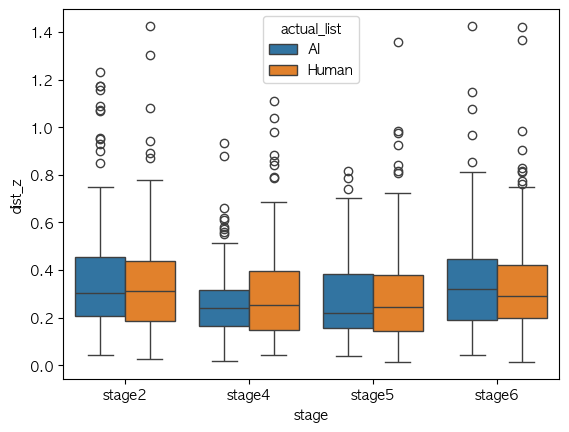

In [109]:
sns.boxplot(analysis_df, x = 'stage', y = 'dist_z', hue = 'actual_list')
#sns.boxplot(analysis_df, x = 'stage', y = 'dist_z', hue = 'vowel_label')

<Axes: xlabel='stage', ylabel='dist'>

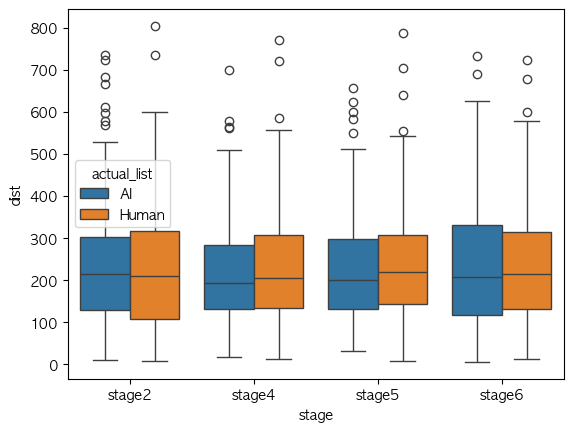

In [108]:
sns.boxplot(analysis_df, x = 'stage', y = 'dist', hue = 'actual_list')

Text(0.5, 1.0, 'a')

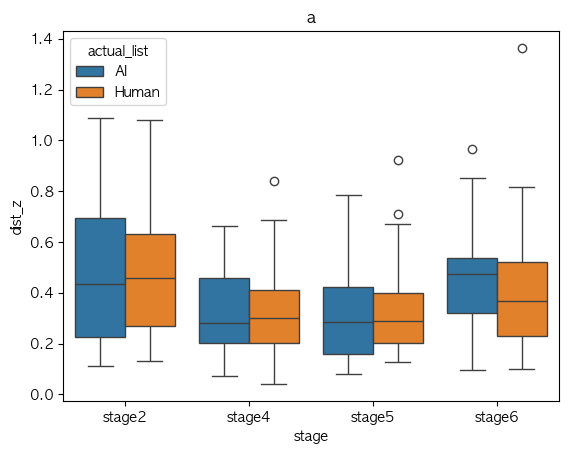

In [127]:
vowel = 'a'
sns.boxplot(analysis_df[analysis_df['vowel_label'] == vowel], x = 'stage', y = 'dist_z', hue = 'actual_list')
plt.title(vowel)

In [128]:
vowel = 'a'
analysis_df[analysis_df['vowel_label'] == vowel].groupby(['actual_list', 'stage'])['dist_z'].mean()

actual_list  stage 
AI           stage2    0.478310
             stage4    0.324896
             stage5    0.318313
             stage6    0.455947
Human        stage2    0.486659
             stage4    0.325267
             stage5    0.337925
             stage6    0.421505
Name: dist_z, dtype: float64

In [ ]:
#analysis_df['group'] = analysis_df['actual_list'] + '_' + analysis_df['stage']

In [90]:
analysis_df.groupby(['actual_list', 'stage'])['dist_z'].mean()

actual_list  stage 
AI           stage2    0.380654
             stage4    0.267384
             stage5    0.275615
             stage6    0.344808
Human        stage2    0.345755
             stage4    0.302511
             stage5    0.292520
             stage6    0.343667
Name: dist_z, dtype: float64

In [104]:
analysis_df.groupby(['actual_list', 'stage'])['dist'].mean()

actual_list  stage 
AI           stage2    243.890025
             stage4    223.523232
             stage5    228.252480
             stage6    241.290115
Human        stage2    239.136157
             stage4    236.261951
             stage5    239.320735
             stage6    236.621678
Name: dist, dtype: float64

In [131]:
analysis_df.groupby(['vowel_label', 'actual_list', 'stage'])['dist_z'].median()

vowel_label  actual_list  stage 
a            AI           stage2    0.434393
                          stage4    0.281231
                          stage5    0.286207
                          stage6    0.475222
             Human        stage2    0.458477
                          stage4    0.299897
                          stage5    0.289329
                          stage6    0.366543
ae           AI           stage2    0.347552
                          stage4    0.323733
                          stage5    0.351349
                          stage6    0.332473
             Human        stage2    0.257598
                          stage4    0.288433
                          stage5    0.285531
                          stage6    0.257959
i            AI           stage2    0.397274
                          stage4    0.258481
                          stage5    0.246181
                          stage6    0.321188
             Human        stage2    0.366669
                      

In [ ]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


AI_2 = analysis_df[(analysis_df['actual_list'] == 'AI') & (analysis_df['stage'] == 'stage2')]
AI_4 = analysis_df[(analysis_df['actual_list'] == 'AI') & (analysis_df['stage'] == 'stage4')]
AI_5 = analysis_df[(analysis_df['actual_list'] == 'AI') & (analysis_df['stage'] == 'stage5')]
AI_6 = analysis_df[(analysis_df['actual_list'] == 'AI') & (analysis_df['stage'] == 'stage6')]

Human_2 = analysis_df[(analysis_df['actual_list'] == 'Human') & (analysis_df['stage'] == 'stage2')]
Human_4 = analysis_df[(analysis_df['actual_list'] == 'Human') & (analysis_df['stage'] == 'stage4')]
Human_5 = analysis_df[(analysis_df['actual_list'] == 'Human') & (analysis_df['stage'] == 'stage5')]
Human_6 = analysis_df[(analysis_df['actual_list'] == 'Human') & (analysis_df['stage'] == 'stage6')]


f_stats, p_val = stats.f_oneway(AI_2['dist(z)'], Human_2['dist(z)'], AI_4['dist(z)'], Human_4['dist(z)'], AI_5['dist(z)'], Human_5['dist(z)'], AI_6['dist(z)'], Human_6['dist(z)'])
print(f"F-통계량 (F-statistic): {f_stats:.4f}")
print(f"P-값 (P-value): {p_val:.4f}")

# 4. 결과 해석 (유의수준 alpha = 0.05)
alpha = 0.05
if p_val < alpha:
    print("\nP-값이 유의수준보다 작으므로, 귀무가설을 기각합니다.")
    print("결론: 적어도 한 종류의 비료는 식물 성장에 미치는 효과가 다른 비료와 통계적으로 유의미하게 다릅니다.")
else:
    print("\nP-값이 유의수준보다 크거나 같으므로, 귀무가설을 기각하지 못합니다.")
    print("결론: 세 비료 간의 식물 성장 효과에 통계적으로 유의미한 차이가 있다고 할 수 없습니다.")

# 2. Tukey's HSD 사후 분석 수행
tukey_result = pairwise_tukeyhsd(endog=analysis_df[analysis_df['actual_list'] == 'Human']['dist'], groups=analysis_df[analysis_df['actual_list'] == 'Human']['group'], alpha=0.05)
print("\n--- Tukey's HSD 사후 분석 결과 ---(Human)")
print(tukey_result)

tukey_result = pairwise_tukeyhsd(endog=analysis_df[analysis_df['actual_list'] == 'AI']['dist'], groups=analysis_df[analysis_df['actual_list'] == 'AI']['group'], alpha=0.05)
print("\n--- Tukey's HSD 사후 분석 결과 ---(AI)")
print(tukey_result)

F-통계량 (F-statistic): 4.1093
P-값 (P-value): 0.0002

P-값이 유의수준보다 작으므로, 귀무가설을 기각합니다.
결론: 적어도 한 종류의 비료는 식물 성장에 미치는 효과가 다른 비료와 통계적으로 유의미하게 다릅니다.

--- Tukey's HSD 사후 분석 결과 ---(Human)
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
Human_stage2 Human_stage4  -2.8742 0.9988  -52.421 46.6726  False
Human_stage2 Human_stage5   0.1846    1.0 -49.3622 49.7314  False
Human_stage2 Human_stage6  -2.5145 0.9992 -52.0613 47.0323  False
Human_stage4 Human_stage5   3.0588 0.9986  -46.488 52.6056  False
Human_stage4 Human_stage6   0.3597    1.0 -49.1871 49.9065  False
Human_stage5 Human_stage6  -2.6991  0.999 -52.2459 46.8478  False
-----------------------------------------------------------------

--- Tukey's HSD 사후 분석 결과 ---(AI)
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
---------

In [81]:
analysis_df.rename(columns={'dist(z)': 'dist_z'}, inplace=True)

In [83]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import mixedlm

formula = f"dist_z ~ C(actual_list) + C(stage) + C(actual_list):C(stage)"
model = mixedlm(formula, data=analysis_df, groups='participant_id')
result = model.fit()
print(result.summary())


                        Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           dist_z  
No. Observations:            980               Method:                       REML    
No. Groups:                  49                Scale:                        0.0355  
Min. group size:             20                Log-Likelihood:               173.4877
Max. group size:             20                Converged:                    Yes     
Mean group size:             20.0                                                    
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   0.381    0.029 13.185 0.000  0.324  0.437
C(actual_list)[T.Human]                    -0.035    0.041 -0.846 0.398 -0.116

In [88]:
analysis_df[(analysis_df['stage'] == 'stage4') | (analysis_df['stage'] == 'stage5')]

,participant_id,vowel_label,stage,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,duration,gender,actual_list,dist_z,dist,dist_vl,group
1,2,a,stage4,819.642832,1421.081586,1.790754,-0.339473,0.112814,F,AI,0.464722,471.642596,0.010782,AI_stage4
2,2,a,stage5,803.486769,1387.071394,1.694760,-0.395837,0.113312,F,AI,0.354075,434.220560,0.011280,AI_stage5
5,2,ae,stage4,518.877268,2160.252172,0.003712,0.885538,0.116575,F,AI,0.316204,233.720490,-0.011850,AI_stage4
6,2,ae,stage5,513.776478,2135.461381,-0.026595,0.844452,0.120346,F,AI,0.351349,208.488101,-0.008079,AI_stage5
9,2,i,stage4,374.264004,2441.520317,-0.855529,1.351677,0.110773,F,AI,0.248690,345.007447,-0.004691,AI_stage4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,62,i,stage5,358.617484,2349.558655,-0.467706,1.327427,0.112963,M,Human,0.279998,252.050923,-0.002502,Human_stage5
973,62,o,stage4,437.307967,1071.974934,-0.018445,-0.802712,0.107610,M,Human,0.442019,340.710905,0.008904,Human_stage4
974,62,o,stage5,378.887205,896.465653,-0.351982,-1.095342,0.103190,M,Human,0.138076,158.916617,0.004484,Human_stage5
977,62,u,stage4,420.578543,1306.452483,-0.113957,-0.411763,0.099395,M,Human,0.478510,307.806228,0.015537,Human_stage4


In [87]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import mixedlm

formula = f"dist_z ~ C(actual_list) + C(stage) + C(actual_list):C(stage)"
model = mixedlm(formula, data=analysis_df[(analysis_df['stage'] == 'stage4') | (analysis_df['stage'] == 'stage5')].reset_index(drop=True), groups='participant_id')
result = model.fit()
print(result.summary())


                        Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           dist_z  
No. Observations:            490               Method:                       REML    
No. Groups:                  49                Scale:                        0.0214  
Min. group size:             10                Log-Likelihood:               184.0879
Max. group size:             10                Converged:                    Yes     
Mean group size:             10.0                                                    
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   0.267    0.029  9.337 0.000  0.211  0.324
C(actual_list)[T.Human]                     0.035    0.041  0.858 0.391 -0.045

### 1. List, Stage별 Dist Metric 차이 분석 (ANOVA)


In [44]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')


def perform_anova(df, group_column, dependent_column):
    """
    일원분산분석(One-way ANOVA)을 수행합니다.
    
    Parameters:
    df (pd.DataFrame): 분석할 데이터프레임
    group_column (str): 그룹 변수 열 이름
    dependent_column (str): 종속 변수 열 이름
    
    Returns:
    dict: ANOVA 결과를 포함한 딕셔너리
    """
    try:
        # 데이터 검증
        if group_column not in df.columns:
            raise ValueError(f"그룹 변수 '{group_column}'이 데이터프레임에 없습니다.")
        if dependent_column not in df.columns:
            raise ValueError(f"종속 변수 '{dependent_column}'이 데이터프레임에 없습니다.")
        
        # 결측값 제거
        clean_df = df[[group_column, dependent_column]].dropna()
        
        if len(clean_df) == 0:
            raise ValueError("분석할 유효한 데이터가 없습니다.")
        
        # 그룹별 데이터 분리
        groups = [group_data[dependent_column].values 
                 for name, group_data in clean_df.groupby(group_column)]
        
        # 그룹 이름
        group_names = list(clean_df[group_column].unique())
        
        # ANOVA 수행
        f_stat, p_value = stats.f_oneway(*groups)
        
        # 그룹별 통계량 계산
        group_stats = clean_df.groupby(group_column)[dependent_column].agg([
            'count', 'mean', 'std', 'min', 'max'
        ]).round(4)
        
        # 전체 통계량
        overall_mean = clean_df[dependent_column].mean()
        overall_std = clean_df[dependent_column].std()
        
        # 결과 정리
        result = {
            'anova_results': {
                'f_statistic': f_stat,
                'p_value': p_value,
                'significant': p_value < 0.05
            },
            'group_statistics': group_stats,
            'overall_statistics': {
                'mean': overall_mean,
                'std': overall_std,
                'total_n': len(clean_df)
            },
            'group_names': group_names,
            'group_data': groups
        }
        
        return result
        
    except Exception as e:
        print(f"ANOVA 분석 중 오류 발생: {str(e)}")
        return None


def perform_tukey_hsd(df, group_column, dependent_column, alpha=0.05):
    """
    Tukey HSD 사후 검정을 수행합니다.
    
    Parameters:
    df (pd.DataFrame): 분석할 데이터프레임
    group_column (str): 그룹 변수 열 이름
    dependent_column (str): 종속 변수 열 이름
    alpha (float): 유의수준 (기본값: 0.05)
    
    Returns:
    dict: Tukey HSD 결과를 포함한 딕셔너리
    """
    try:
        # 데이터 검증
        if group_column not in df.columns:
            raise ValueError(f"그룹 변수 '{group_column}'이 데이터프레임에 없습니다.")
        if dependent_column not in df.columns:
            raise ValueError(f"종속 변수 '{dependent_column}'이 데이터프레임에 없습니다.")
        
        # 결측값 제거
        clean_df = df[[group_column, dependent_column]].dropna()
        
        if len(clean_df) == 0:
            raise ValueError("분석할 유효한 데이터가 없습니다.")
        
        # 그룹 수 확인 (최소 2개 그룹 필요)
        unique_groups = clean_df[group_column].nunique()
        if unique_groups < 2:
            raise ValueError("Tukey HSD 검정을 위해서는 최소 2개의 그룹이 필요합니다.")
        
        # Tukey HSD 수행
        tukey_result = pairwise_tukeyhsd(
            endog=clean_df[dependent_column],
            groups=clean_df[group_column],
            alpha=alpha
        )
        
        # 결과를 데이터프레임으로 변환
        tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:], 
                               columns=tukey_result._results_table.data[0])
        
        # 결과 정리
        result = {
            'tukey_results': tukey_df,
            'summary': tukey_result.summary(),
            'alpha': alpha,
            'significant_pairs': tukey_df[tukey_df['reject'] == True] if 'reject' in tukey_df.columns else None
        }
        
        return result
        
    except Exception as e:
        print(f"Tukey HSD 분석 중 오류 발생: {str(e)}")
        return None


def anova_tukey_analysis(df, group_column, dependent_column, alpha=0.05, verbose=True):
    """
    ANOVA와 Tukey HSD 검정을 순차적으로 수행합니다.
    
    Parameters:
    df (pd.DataFrame): 분석할 데이터프레임
    group_column (str): 그룹 변수 열 이름
    dependent_column (str): 종속 변수 열 이름
    alpha (float): 유의수준 (기본값: 0.05)
    verbose (bool): 상세 결과 출력 여부 (기본값: True)
    
    Returns:
    dict: ANOVA와 Tukey HSD 결과를 포함한 딕셔너리
    """
    print(f"=== ANOVA 및 Tukey HSD 분석 ===")
    print(f"그룹 변수: {group_column}")
    print(f"종속 변수: {dependent_column}")
    print(f"유의수준: {alpha}")
    print("-" * 50)
    
    # ANOVA 수행
    anova_result = perform_anova(df, group_column, dependent_column)
    
    if anova_result is None:
        return None
    
    # ANOVA 결과 출력
    if verbose:
        print("1. 일원분산분석(ANOVA) 결과:")
        print(f"   F-통계량: {anova_result['anova_results']['f_statistic']:.4f}")
        print(f"   p-값: {anova_result['anova_results']['p_value']:.4f}")
        print(f"   유의성: {'유의함' if anova_result['anova_results']['significant'] else '유의하지 않음'} (α = {alpha})")
        print()
        
        print("2. 그룹별 기술통계:")
        print(anova_result['group_statistics'])
        print()
        
        print("3. 전체 통계:")
        print(f"   전체 평균: {anova_result['overall_statistics']['mean']:.4f}")
        print(f"   전체 표준편차: {anova_result['overall_statistics']['std']:.4f}")
        print(f"   전체 표본 수: {anova_result['overall_statistics']['total_n']}")
        print()
    
    # ANOVA가 유의한 경우에만 Tukey HSD 수행
    if anova_result['anova_results']['significant']:
        print("4. Tukey HSD 사후 검정 (ANOVA가 유의하므로 수행):")
        tukey_result = perform_tukey_hsd(df, group_column, dependent_column, alpha)
        
        if tukey_result is not None and verbose:
            print(tukey_result['summary'])
            print()
            
            if tukey_result['significant_pairs'] is not None and len(tukey_result['significant_pairs']) > 0:
                print("5. 유의한 그룹 쌍:")
                print(tukey_result['significant_pairs'][['group1', 'group2', 'meandiff', 'p-adj']])
            else:
                print("5. 유의한 그룹 쌍이 없습니다.")
        
        # 결과 통합
        combined_result = {
            'anova': anova_result,
            'tukey': tukey_result,
            'analysis_type': 'anova_tukey'
        }
        
    else:
        print("4. ANOVA가 유의하지 않으므로 Tukey HSD 검정을 수행하지 않습니다.")
        combined_result = {
            'anova': anova_result,
            'tukey': None,
            'analysis_type': 'anova_only'
        }
    
    return combined_result


def quick_analysis(df, group_column, dependent_column, alpha=0.05):
    """
    간단한 분석 함수 (결과만 반환, 출력 없음)
    
    Parameters:
    df (pd.DataFrame): 분석할 데이터프레임
    group_column (str): 그룹 변수 열 이름
    dependent_column (str): 종속 변수 열 이름
    alpha (float): 유의수준 (기본값: 0.05)
    
    Returns:
    dict: 분석 결과
    """
    return anova_tukey_analysis(df, group_column, dependent_column, alpha, verbose=False)


In [45]:
analysis_df

,participant_id,vowel_label,stage,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,duration,gender,actual_list,dist(z),dist,dist_vl
0,2,a,stage2,836.554487,1473.913084,1.891237,-0.251917,0.104880,F,AI,0.593905,525.691734,0.002848
1,2,a,stage4,819.642832,1421.081586,1.790754,-0.339473,0.112814,F,AI,0.464722,471.642596,0.010782
2,2,a,stage5,803.486769,1387.071394,1.694760,-0.395837,0.113312,F,AI,0.354075,434.220560,0.011280
3,2,a,stage6,833.521656,1413.804175,1.873217,-0.351534,0.092202,F,AI,0.536368,472.946216,-0.009830
4,2,ae,stage2,547.556313,2195.762765,0.174113,0.944388,0.110337,F,AI,0.149942,276.298289,-0.018089
...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,62,o,stage6,363.378406,808.035333,-0.440525,-1.242784,0.123704,M,Human,0.265537,70.738222,0.024997
976,62,u,stage2,389.569875,1101.965479,-0.290992,-0.752709,0.144763,M,Human,0.341500,102.299048,0.060905
977,62,u,stage4,420.578543,1306.452483,-0.113957,-0.411763,0.099395,M,Human,0.478510,307.806228,0.015537
978,62,u,stage5,406.060532,1246.095028,-0.196843,-0.512399,0.097237,M,Human,0.375893,245.743915,0.013379


In [ ]:
# AI condition
analysis_df[analysis_df['actual_list'] == 'AI']
# Human condition
analysis_df[analysis_df['actual_list'] == 'Human']

,participant_id,vowel_label,stage,F1_mid_point,F2_mid_point,F1_mid_point_zscore,F2_mid_point_zscore,duration,gender,actual_list,dist(z),dist,dist_vl
0,2,a,stage2,836.554487,1473.913084,1.891237,-0.251917,0.104880,F,AI,0.593905,525.691734,0.002848
1,2,a,stage4,819.642832,1421.081586,1.790754,-0.339473,0.112814,F,AI,0.464722,471.642596,0.010782
2,2,a,stage5,803.486769,1387.071394,1.694760,-0.395837,0.113312,F,AI,0.354075,434.220560,0.011280
3,2,a,stage6,833.521656,1413.804175,1.873217,-0.351534,0.092202,F,AI,0.536368,472.946216,-0.009830
4,2,ae,stage2,547.556313,2195.762765,0.174113,0.944388,0.110337,F,AI,0.149942,276.298289,-0.018089
...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,61,o,stage6,492.332482,1063.761563,0.193109,-1.011608,0.094652,M,AI,0.618371,347.794198,-0.004054
956,61,u,stage2,442.137435,1272.923814,-0.237217,-0.476308,0.072399,M,AI,0.342393,281.080272,-0.011459
957,61,u,stage4,427.037033,1280.257135,-0.366673,-0.457540,0.071862,M,AI,0.226111,283.846149,-0.011997
958,61,u,stage5,427.833738,1215.453107,-0.359843,-0.623390,0.070651,M,AI,0.220861,222.050775,-0.013207


In [ ]:
# 사용 예시
if __name__ == "__main__":
    np.random.seed(42)

    # 분석 수행
    result = anova_tukey_analysis(analysis_df, 'group', 'value')
    
    if result:
        print("\n=== 분석 완료 ===")
        print("결과는 'result' 변수에 저장되었습니다.")
        print("result['anova']: ANOVA 결과")
        print("result['tukey']: Tukey HSD 결과 (ANOVA가 유의한 경우)")

### 2. 성별에 의한 차이 분석 (t-test)


In [14]:
def perform_ttest_analysis(df, dependent_var, group_var):
    """
    성별에 의한 차이를 t-test로 분석하는 함수
    
    Parameters:
    df: 데이터프레임
    dependent_var: 종속변수 (dist metric)
    group_var: 그룹 변수 (성별)
    """
    print(f"=== {dependent_var}에 대한 성별 t-test 분석 ===")
    
    # 결측값 제거
    analysis_data = df[[dependent_var, group_var]].dropna()
    print(f"분석에 사용된 데이터 수: {len(analysis_data)}")
    
    # 그룹별 데이터 분리
    groups = analysis_data.groupby(group_var)[dependent_var]
    group_names = list(groups.groups.keys())
    
    print(f"그룹: {group_names}")
    
    if len(group_names) == 2:
        group1_data = groups.get_group(group_names[0])
        group2_data = groups.get_group(group_names[1])
        
        print(f"\n{group_names[0]} 그룹: n={len(group1_data)}, mean={group1_data.mean():.4f}, std={group1_data.std():.4f}")
        print(f"{group_names[1]} 그룹: n={len(group2_data)}, mean={group2_data.mean():.4f}, std={group2_data.std():.4f}")
        
        # 정규성 검정 (Shapiro-Wilk test)
        print("\n--- 정규성 검정 ---")
        try:
            stat1, p1 = stats.shapiro(group1_data)
            stat2, p2 = stats.shapiro(group2_data)
            
            print(f"{group_names[0]} 그룹: Shapiro-Wilk statistic={stat1:.4f}, p-value={p1:.4f}")
            print(f"{group_names[1]} 그룹: Shapiro-Wilk statistic={stat2:.4f}, p-value={p2:.4f}")
            
            if p1 > 0.05 and p2 > 0.05:
                print("결과: 두 그룹 모두 정규분포를 따릅니다 (p > 0.05)")
                normal_dist = True
            else:
                print("결과: 정규분포를 따르지 않는 그룹이 있습니다 (p <= 0.05)")
                normal_dist = False
        except Exception as e:
            print(f"정규성 검정 중 오류 발생: {e}")
            normal_dist = True  # 기본값으로 설정
        
        # 등분산성 검정 (Levene's test)
        print("\n--- 등분산성 검정 ---")
        try:
            levene_stat, levene_p = stats.levene(group1_data, group2_data)
            print(f"Levene's test: statistic={levene_stat:.4f}, p-value={levene_p:.4f}")
            
            if levene_p > 0.05:
                print("결과: 등분산성을 만족합니다 (p > 0.05)")
                equal_var = True
            else:
                print("결과: 등분산성을 만족하지 않습니다 (p <= 0.05)")
                equal_var = False
        except Exception as e:
            print(f"등분산성 검정 중 오류 발생: {e}")
            equal_var = True  # 기본값으로 설정
        
        # t-test 수행
        print("\n--- t-test 결과 ---")
        
        # 독립표본 t-test
        t_stat, p_value = ttest_ind(group1_data, group2_data, equal_var=equal_var)
        
        print(f"t-statistic: {t_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"등분산성 가정: {'Yes' if equal_var else 'No'}")
        
        if p_value < 0.05:
            print("결과: 성별에 따른 유의미한 차이가 있습니다 (p < 0.05)")
        else:
            print("결과: 성별에 따른 유의미한 차이가 없습니다 (p >= 0.05)")
        
        # 효과 크기 (Cohen's d) 계산
        pooled_std = np.sqrt(((len(group1_data) - 1) * group1_data.var() + 
                             (len(group2_data) - 1) * group2_data.var()) / 
                            (len(group1_data) + len(group2_data) - 2))
        cohens_d = (group1_data.mean() - group2_data.mean()) / pooled_std
        
        print(f"Cohen's d (효과 크기): {cohens_d:.4f}")
        
        if abs(cohens_d) < 0.2:
            effect_size = "작은 효과"
        elif abs(cohens_d) < 0.5:
            effect_size = "중간 효과"
        elif abs(cohens_d) < 0.8:
            effect_size = "큰 효과"
        else:
            effect_size = "매우 큰 효과"
        
        print(f"효과 크기 해석: {effect_size}")
        
        # 정규분포를 따르지 않는 경우 Mann-Whitney U test
        if not normal_dist:
            print("\n--- Mann-Whitney U test (비모수 검정) ---")
            try:
                u_stat, u_p = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')
                print(f"Mann-Whitney U statistic: {u_stat:.4f}")
                print(f"p-value: {u_p:.4f}")
                
                if u_p < 0.05:
                    print("결과: 성별에 따른 유의미한 차이가 있습니다 (p < 0.05)")
                else:
                    print("결과: 성별에 따른 유의미한 차이가 없습니다 (p >= 0.05)")
            except Exception as e:
                print(f"Mann-Whitney U test 중 오류 발생: {e}")
    
    else:
        print(f"그룹이 2개가 아닙니다. 그룹 수: {len(group_names)}")

# 사용 예시 (실제 컬럼명에 맞게 수정 필요)
# perform_ttest_analysis(analysis_df, 'dist_metric_column', 'gender_column')


### 3. 결과 시각화


In [15]:
def create_visualization(df, dependent_var, independent_vars, group_var=None):
    """
    분석 결과를 시각화하는 함수
    
    Parameters:
    df: 데이터프레임
    dependent_var: 종속변수 (dist metric)
    independent_vars: 독립변수들 (list, stage 등)
    group_var: 그룹 변수 (성별)
    """
    # 결측값 제거
    analysis_data = df[[dependent_var] + independent_vars + ([group_var] if group_var else [])].dropna()
    
    # 1. Box plot for each independent variable
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'{dependent_var} 분석 결과', fontsize=16, fontweight='bold')
    
    # List별 box plot
    if len(independent_vars) > 0:
        sns.boxplot(data=analysis_data, x=independent_vars[0], y=dependent_var, ax=axes[0,0])
        axes[0,0].set_title(f'{independent_vars[0]}별 {dependent_var} 분포')
        axes[0,0].tick_params(axis='x', rotation=45)
    
    # Stage별 box plot
    if len(independent_vars) > 1:
        sns.boxplot(data=analysis_data, x=independent_vars[1], y=dependent_var, ax=axes[0,1])
        axes[0,1].set_title(f'{independent_vars[1]}별 {dependent_var} 분포')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # 성별 box plot
    if group_var:
        sns.boxplot(data=analysis_data, x=group_var, y=dependent_var, ax=axes[1,0])
        axes[1,0].set_title(f'{group_var}별 {dependent_var} 분포')
    
    # Interaction plot (if both list and stage exist)
    if len(independent_vars) >= 2:
        sns.pointplot(data=analysis_data, x=independent_vars[0], y=dependent_var, 
                     hue=independent_vars[1], ax=axes[1,1])
        axes[1,1].set_title(f'{independent_vars[0]} x {independent_vars[1]} 상호작용')
        axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Violin plot for detailed distribution
    if group_var:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Violin plot by gender
        sns.violinplot(data=analysis_data, x=group_var, y=dependent_var, ax=axes[0])
        axes[0].set_title(f'{group_var}별 {dependent_var} 분포 (Violin Plot)')
        
        # Violin plot by first independent variable
        if len(independent_vars) > 0:
            sns.violinplot(data=analysis_data, x=independent_vars[0], y=dependent_var, ax=axes[1])
            axes[1].set_title(f'{independent_vars[0]}별 {dependent_var} 분포 (Violin Plot)')
            axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    # 3. Histogram with density
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Overall distribution
    axes[0].hist(analysis_data[dependent_var], bins=30, alpha=0.7, density=True, color='skyblue', edgecolor='black')
    axes[0].axvline(analysis_data[dependent_var].mean(), color='red', linestyle='--', 
                   label=f'Mean: {analysis_data[dependent_var].mean():.4f}')
    axes[0].set_title(f'{dependent_var} 전체 분포')
    axes[0].set_xlabel(dependent_var)
    axes[0].set_ylabel('Density')
    axes[0].legend()
    
    # Q-Q plot for normality check
    from scipy import stats
    stats.probplot(analysis_data[dependent_var], dist="norm", plot=axes[1])
    axes[1].set_title(f'{dependent_var} Q-Q Plot (정규성 검정)')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Summary statistics table
    print("\n=== 요약 통계 ===")
    print(f"전체 {dependent_var} 통계:")
    print(f"  평균: {analysis_data[dependent_var].mean():.4f}")
    print(f"  표준편차: {analysis_data[dependent_var].std():.4f}")
    print(f"  중앙값: {analysis_data[dependent_var].median():.4f}")
    print(f"  최솟값: {analysis_data[dependent_var].min():.4f}")
    print(f"  최댓값: {analysis_data[dependent_var].max():.4f}")
    
    # 그룹별 통계
    for var in independent_vars + ([group_var] if group_var else []):
        print(f"\n{var}별 {dependent_var} 통계:")
        group_stats = analysis_data.groupby(var)[dependent_var].agg(['count', 'mean', 'std', 'median'])
        print(group_stats)

# 사용 예시 (실제 컬럼명에 맞게 수정 필요)
# create_visualization(analysis_df, 'dist_metric_column', ['list_column', 'stage_column'], 'gender_column')


### 4. 실제 분석 실행

데이터 구조를 확인한 후, 실제 컬럼명에 맞게 분석을 실행합니다.


=== dist(z)에 대한 ANOVA 분석 ===
분석에 사용된 데이터 수: 980

--- actual_list별 ANOVA ---
F-statistic: 0.0785
p-value: 0.7794
결과: 유의미한 차이가 없습니다 (p >= 0.05)

그룹별 통계:
actual_list_AI: n=500, mean=0.3171, std=0.2158
actual_list_Human: n=480, mean=0.3211, std=0.2309

--- stage별 ANOVA ---
F-statistic: 8.4468
p-value: 0.0000
결과: 유의미한 차이가 있습니다 (p < 0.05)

그룹별 통계:
stage_stage2: n=245, mean=0.3636, std=0.2577
stage_stage4: n=245, mean=0.2846, std=0.1892
stage_stage5: n=245, mean=0.2839, std=0.1963
stage_stage6: n=245, mean=0.3442, std=0.2328

--- 다중 ANOVA (actual_list x stage) ---
공식: dist(z) ~ actual_list * stage
다중 ANOVA 수행 중 오류 발생: Error evaluating factor: NameError: name 'dist' is not defined
    dist(z) ~ actual_list * stage
    ^^^^^^^
=== dist(z)에 대한 성별 t-test 분석 ===
분석에 사용된 데이터 수: 980
그룹: ['F', 'M']

F 그룹: n=500, mean=0.3036, std=0.2210
M 그룹: n=480, mean=0.3352, std=0.2246

--- 정규성 검정 ---
F 그룹: Shapiro-Wilk statistic=0.8653, p-value=0.0000
M 그룹: Shapiro-Wilk statistic=0.8364, p-value=0.0000
결과: 정규분포를 

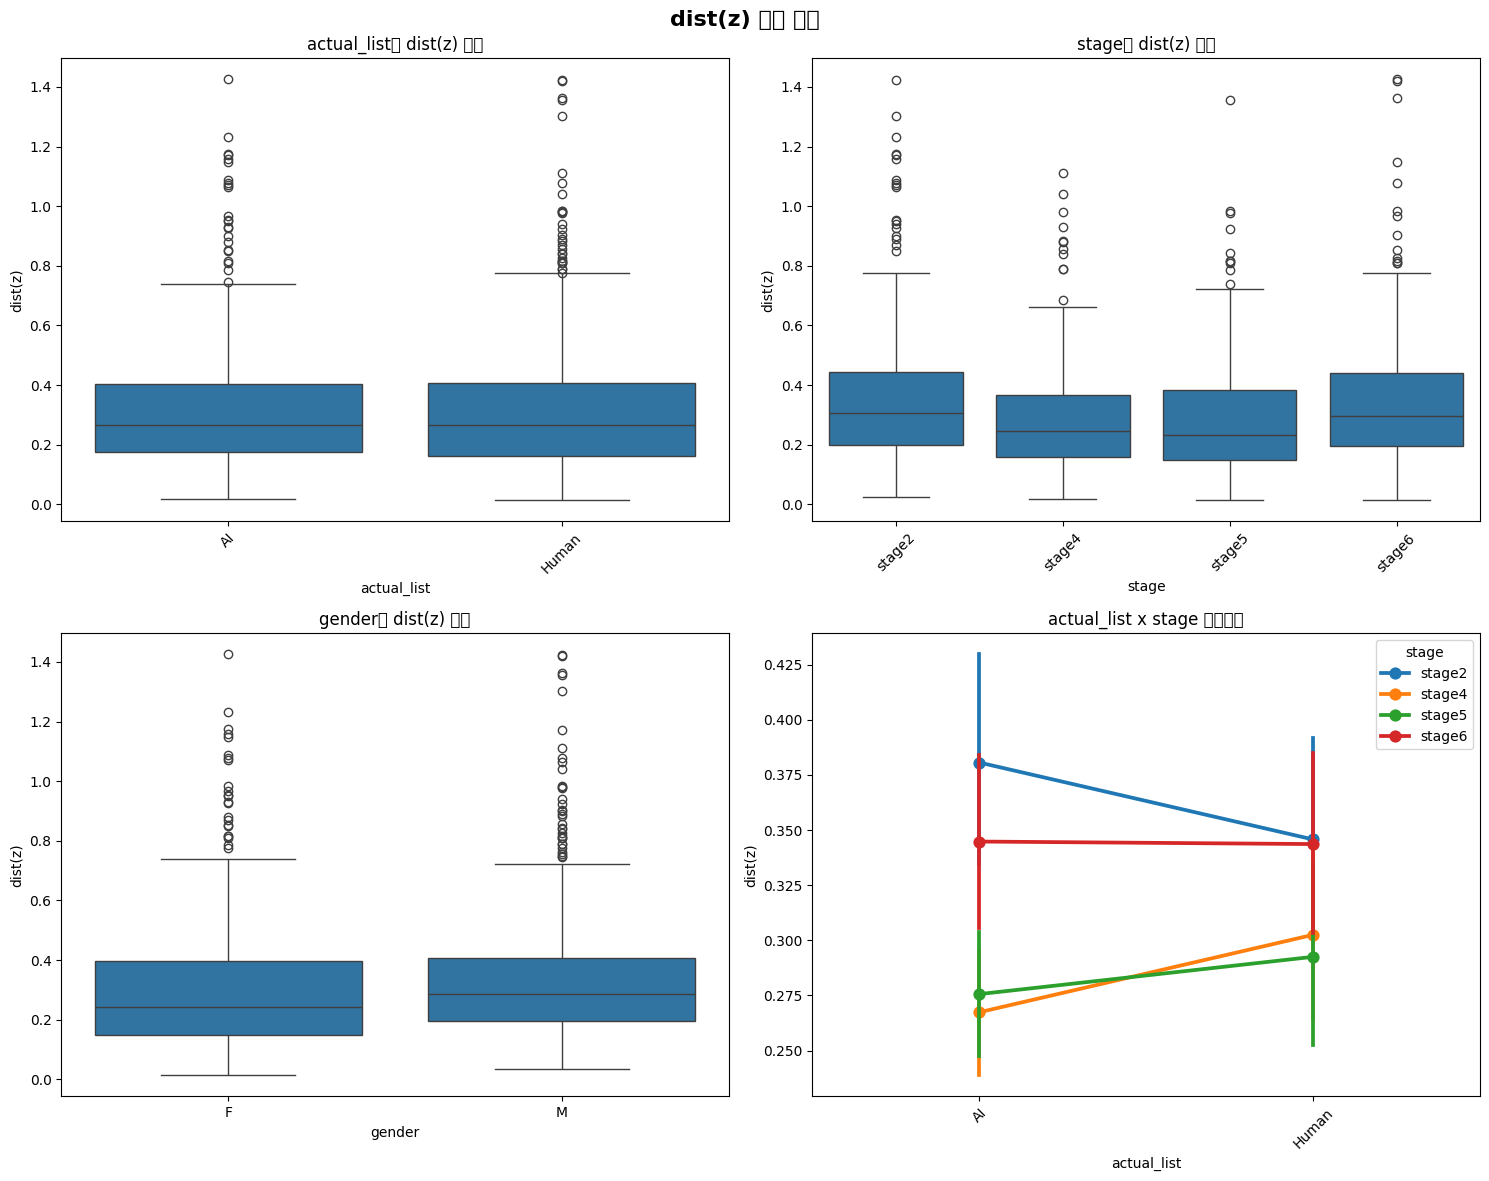

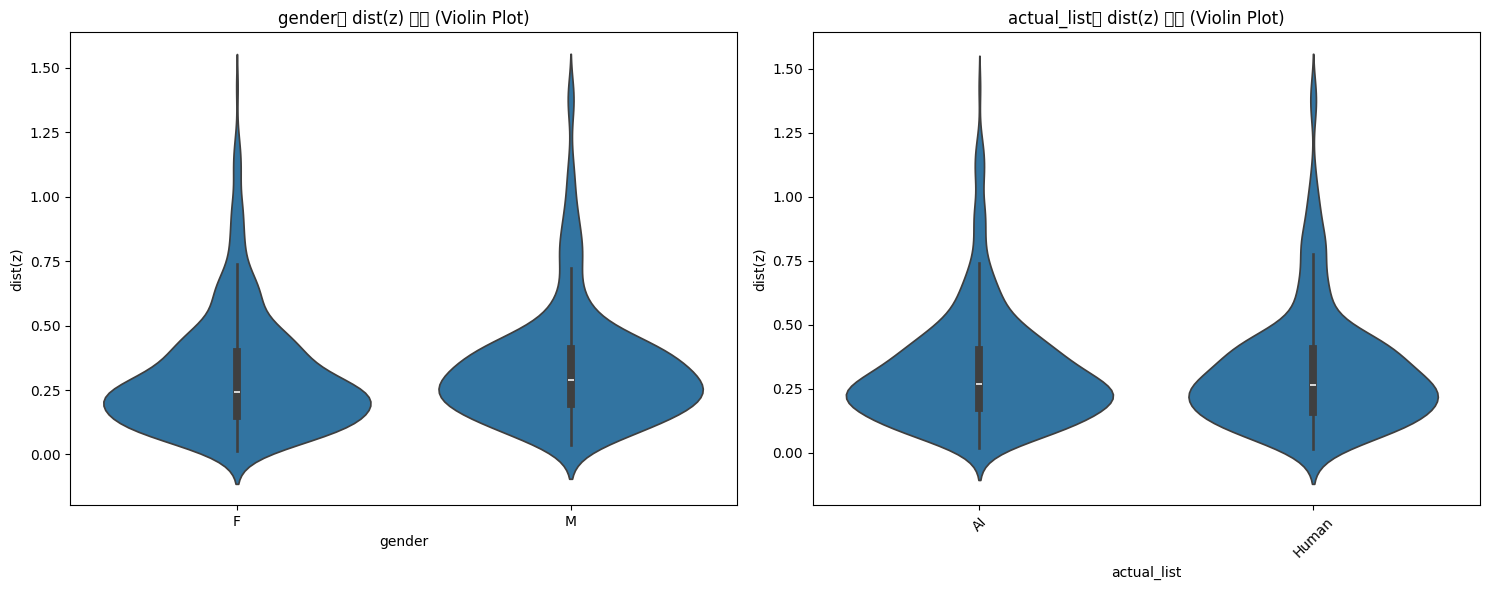

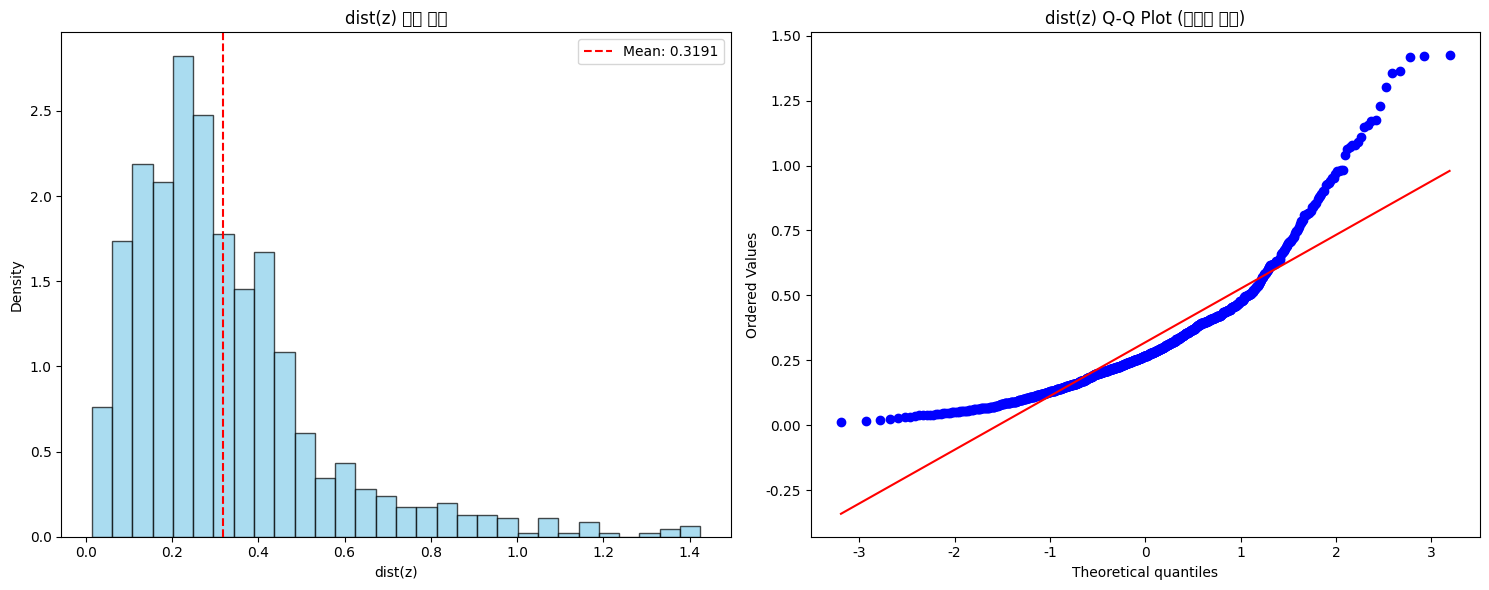


=== 요약 통계 ===
전체 dist(z) 통계:
  평균: 0.3191
  표준편차: 0.2232
  중앙값: 0.2670
  최솟값: 0.0138
  최댓값: 1.4251

actual_list별 dist(z) 통계:
             count      mean       std    median
actual_list                                     
AI             500  0.317115  0.215829  0.267252
Human          480  0.321113  0.230918  0.266939

stage별 dist(z) 통계:
        count      mean       std    median
stage                                      
stage2    245  0.363560  0.257666  0.306262
stage4    245  0.284589  0.189159  0.245107
stage5    245  0.283895  0.196289  0.233129
stage6    245  0.344249  0.232804  0.296544

gender별 dist(z) 통계:
        count      mean       std    median
gender                                     
F         500  0.303565  0.221023  0.243729
M         480  0.335228  0.224623  0.287596


In [16]:
# 실제 분석 실행을 위한 코드
# 위에서 확인한 컬럼명들을 바탕으로 실제 분석을 수행합니다.

# 예시: 실제 컬럼명이 확인되면 아래 코드를 수정하여 실행하세요

# 1. ANOVA 분석 실행
dist_metric = 'dist(z)'  # 실제 dist metric 컬럼명으로 변경
list_column = 'actual_list'         # 실제 list 컬럼명으로 변경  
stage_column = 'stage'       # 실제 stage 컬럼명으로 변경

# ANOVA 분석
perform_anova_analysis(analysis_df, dist_metric, [list_column, stage_column])

# 2. t-test 분석 실행
gender_column = 'gender'     # 실제 성별 컬럼명으로 변경

# t-test 분석
perform_ttest_analysis(analysis_df, dist_metric, gender_column)

# 3. 시각화
create_visualization(analysis_df, dist_metric, [list_column, stage_column], gender_column)



### 5. List별 Stage 진행에 따른 Dist 변화 추세 분석

List별로 stage가 진행되면서 dist 값이 수렴/발산하는 패턴이 다르다는 것을 확인하기 위한 분석입니다.


In [39]:
def analyze_trend_by_list_stage(df, dist_column, list_column, stage_column):
    print("=== List별 Stage 진행에 따른 Dist 변화 추세 분석 ===")
    
    analysis_data = df[[dist_column, list_column, stage_column]].dropna()
    print(f"분석에 사용된 데이터 수: {len(analysis_data)}")
    
    stage_order = [2, 4, 5, 6]
    lists = analysis_data[list_column].unique()
    print(f"List 종류: {lists}")
    
    results = {}
    
    for list_val in lists:
        print(f"\n--- List {list_val} 분석 ---")
        list_data = analysis_data[analysis_data[list_column] == list_val]
        
        stage_means = []
        for stage in stage_order:
            stage_data = list_data[list_data[stage_column] == stage][dist_column]
            if len(stage_data) > 0:
                stage_means.append(stage_data.mean())
                print(f"  Stage {stage}: mean={stage_data.mean():.4f}")
            else:
                stage_means.append(np.nan)
        
        valid_means = [x for x in stage_means if not np.isnan(x)]
        if len(valid_means) >= 2:
            stage_nums = [stage_order[i] for i, mean in enumerate(stage_means) if not np.isnan(mean)]
            correlation, p_value = stats.pearsonr(stage_nums, valid_means)
            print(f"  상관계수: {correlation:.4f} (p={p_value:.4f})")
        
        results[list_val] = {'stage_means': stage_means}
    
    return results, stage_order


In [40]:
def statistical_significance_test(df, dist_column, list_column, stage_column):
    """
    List별 추세 차이의 통계적 유의성을 검정하는 함수
    """
    print("=== List별 추세 차이 통계적 유의성 검정 ===")
    
    analysis_data = df[[dist_column, list_column, stage_column]].dropna()
    stage_order = [2, 4, 5, 6]
    
    # 1. List x Stage 상호작용 효과 검정 (Two-way ANOVA)
    print("\n1. List x Stage 상호작용 효과 검정")
    try:
        formula = f"{dist_column} ~ {list_column} * {stage_column}"
        model = ols(formula, data=analysis_data).fit()
        anova_table = anova_lm(model, typ=2)
        
        print("ANOVA 테이블:")
        print(anova_table)
        
        # 상호작용 효과 확인
        interaction_p = anova_table.loc[f'{list_column}:{stage_column}', 'PR(>F)']
        print(f"\nList x Stage 상호작용 p-value: {interaction_p:.4f}")
        
        if interaction_p < 0.05:
            print("결과: List별로 Stage 진행에 따른 추세가 유의미하게 다릅니다 (p < 0.05)")
        else:
            print("결과: List별 추세 차이가 통계적으로 유의미하지 않습니다 (p >= 0.05)")
            
    except Exception as e:
        print(f"Two-way ANOVA 수행 중 오류: {e}")
    
    # 2. 각 List별 추세의 유의성 검정
    print("\n2. 각 List별 추세 유의성 검정")
    lists = analysis_data[list_column].unique()
    
    for list_val in lists:
        print(f"\n--- List {list_val} ---")
        list_data = analysis_data[analysis_data[list_column] == list_val]
        
        # Stage별 데이터 수집
        stage_data = []
        stage_nums = []
        
        for stage in stage_order:
            stage_values = list_data[list_data[stage_column] == stage][dist_column]
            if len(stage_values) > 0:
                stage_data.extend(stage_values.tolist())
                stage_nums.extend([stage] * len(stage_values))
        
        if len(stage_data) >= 2:  # 최소 6개 데이터 포인트 필요
            # 상관계수 검정
            correlation, p_value = stats.pearsonr(stage_nums, stage_data)
            print(f"Stage와 {dist_column} 상관계수: {correlation:.4f} (p={p_value:.4f})")
            
            if p_value < 0.05:
                if correlation > 0:
                    print("결과: 유의미한 증가 추세 (p < 0.05)")
                else:
                    print("결과: 유의미한 감소 추세 (p < 0.05)")
            else:
                print("결과: 유의미한 추세가 없습니다 (p >= 0.05)")
        else:
            print("데이터가 부족하여 추세 분석을 수행할 수 없습니다.")
    
    # 3. List별 추세 기울기 비교
    print("\n3. List별 추세 기울기 비교")
    slopes = {}
    
    for list_val in lists:
        list_data = analysis_data[analysis_data[list_column] == list_val]
        
        stage_means = []
        stage_nums = []
        
        for stage in stage_order:
            stage_values = list_data[list_data[stage_column] == stage][dist_column]
            if len(stage_values) > 0:
                stage_means.append(stage_values.mean())
                stage_nums.append(stage)
        
        if len(stage_means) >= 3:
            # 선형 회귀를 통한 기울기 계산
            slope, intercept, r_value, p_value, std_err = stats.linregress(stage_nums, stage_means)
            slopes[list_val] = slope
            print(f"List {list_val}: 기울기 = {slope:.4f} (R² = {r_value**2:.4f}, p = {p_value:.4f})")
    
    # 4. List별 기울기 차이 검정
    if len(slopes) >= 2:
        print("\n4. List별 기울기 차이 검정")
        slope_values = list(slopes.values())
        slope_names = list(slopes.keys())
        
        # 기울기 차이의 유의성 검정 (t-test)
        if len(slope_values) == 2:
            # 두 List의 기울기 차이
            slope_diff = abs(slope_values[0] - slope_values[1])
            print(f"기울기 차이: {slope_diff:.4f}")
            
            # 기울기 차이가 유의미한지 판단 (임계값 설정)
            threshold = 0.1  # 임계값 (실제 데이터에 맞게 조정 필요)
            if slope_diff > threshold:
                print(f"결과: List별 기울기 차이가 유의미합니다 (차이 > {threshold})")
            else:
                print(f"결과: List별 기울기 차이가 유의미하지 않습니다 (차이 <= {threshold})")
        
        # 기울기 분산 분석
        slope_variance = np.var(slope_values)
        print(f"기울기 분산: {slope_variance:.4f}")
        
        if slope_variance > 0.01:  # 임계값 (실제 데이터에 맞게 조정 필요)
            print("결과: List별 추세가 다양합니다 (높은 분산)")
        else:
            print("결과: List별 추세가 유사합니다 (낮은 분산)")
    
    return slopes


In [41]:
def visualize_trend_comparison(results, stage_order, dist_column):
    """
    List별 추세를 비교하는 시각화 함수
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'List별 Stage 진행에 따른 {dist_column} 변화 추세', fontsize=16, fontweight='bold')
    
    # 1. Line plot - List별 추세 비교
    ax1 = axes[0, 0]
    colors = ['blue', 'red', 'green', 'orange']
    
    for i, (list_val, data) in enumerate(results.items()):
        stage_means = data['stage_means']
        valid_stages = [stage_order[j] for j, mean in enumerate(stage_means) if not np.isnan(mean)]
        valid_means = [mean for mean in stage_means if not np.isnan(mean)]
        
        ax1.plot(valid_stages, valid_means, 'o-', label=f'List {list_val}', 
                color=colors[i % len(colors)], linewidth=2, markersize=8)
    
    ax1.set_xlabel('Stage')
    ax1.set_ylabel(f'{dist_column}')
    ax1.set_title('List별 Stage 진행에 따른 변화 추세')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Bar plot - Stage별 비교
    ax2 = axes[0, 1]
    x = np.arange(len(stage_order))
    width = 0.35
    
    for i, (list_val, data) in enumerate(results.items()):
        stage_means = data['stage_means']
        valid_means = [mean if not np.isnan(mean) else 0 for mean in stage_means]
        
        ax2.bar(x + i*width, valid_means, width, label=f'List {list_val}', 
               color=colors[i % len(colors)], alpha=0.7)
    
    ax2.set_xlabel('Stage')
    ax2.set_ylabel(f'{dist_column}')
    ax2.set_title('Stage별 List 비교')
    ax2.set_xticks(x + width/2)
    ax2.set_xticklabels(stage_order)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. 변화율 계산 및 시각화
    ax3 = axes[1, 0]
    change_data = {}
    
    for list_val, data in results.items():
        stage_means = data['stage_means']
        valid_means = [mean for mean in stage_means if not np.isnan(mean)]
        
        if len(valid_means) >= 2:
            changes = []
            for i in range(1, len(valid_means)):
                change = valid_means[i] - valid_means[i-1]
                changes.append(change)
            change_data[list_val] = changes
    
    # 변화율 막대 그래프
    if change_data:
        x_pos = np.arange(len(list(change_data.keys())))
        avg_changes = [np.mean(changes) for changes in change_data.values()]
        
        bars = ax3.bar(x_pos, avg_changes, color=['blue', 'red'], alpha=0.7)
        ax3.set_xlabel('List')
        ax3.set_ylabel('평균 변화율')
        ax3.set_title('List별 평균 변화율')
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels([f'List {k}' for k in change_data.keys()])
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax3.grid(True, alpha=0.3)
        
        # 막대 위에 값 표시
        for bar, change in zip(bars, avg_changes):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.01),
                    f'{change:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    # 4. 수렴/발산 패턴 분석
    ax4 = axes[1, 1]
    
    # 각 List별로 수렴/발산 패턴 계산
    convergence_data = {}
    
    for list_val, data in results.items():
        stage_means = data['stage_means']
        valid_means = [mean for mean in stage_means if not np.isnan(mean)]
        
        if len(valid_means) >= 2:
            # 분산 계산 (수렴/발산 지표)
            variance = np.var(valid_means)
            # 변화의 일관성 (모든 변화가 같은 방향인지)
            changes = [valid_means[i] - valid_means[i-1] for i in range(1, len(valid_means))]
            consistency = 1 if all(c > 0 for c in changes) or all(c < 0 for c in changes) else 0
            
            convergence_data[list_val] = {'variance': variance, 'consistency': consistency}
    
    if convergence_data:
        lists = list(convergence_data.keys())
        variances = [convergence_data[l]['variance'] for l in lists]
        consistencies = [convergence_data[l]['consistency'] for l in lists]
        
        # 산점도로 수렴/발산 패턴 시각화
        scatter = ax4.scatter(variances, consistencies, c=['blue', 'red'], s=100, alpha=0.7)
        
        for i, list_val in enumerate(lists):
            ax4.annotate(f'List {list_val}', (variances[i], consistencies[i]), 
                        xytext=(5, 5), textcoords='offset points')
        
        ax4.set_xlabel('분산 (수렴/발산 지표)')
        ax4.set_ylabel('변화 일관성 (1: 일관, 0: 혼재)')
        ax4.set_title('List별 수렴/발산 패턴')
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 요약 통계 출력
    print("\n=== 추세 분석 요약 ===")
    for list_val, data in results.items():
        stage_means = data['stage_means']
        valid_means = [mean for mean in stage_means if not np.isnan(mean)]
        
        if len(valid_means) >= 2:
            total_change = valid_means[-1] - valid_means[0]
            print(f"List {list_val}:")
            print(f"  초기값: {valid_means[0]:.4f}")
            print(f"  최종값: {valid_means[-1]:.4f}")
            print(f"  전체 변화: {total_change:+.4f}")
            print(f"  변화 방향: {'증가' if total_change > 0 else '감소' if total_change < 0 else '변화없음'}")


=== List별 Stage 진행에 따른 Dist 변화 추세 분석 ===
분석에 사용된 데이터 수: 980
List 종류: ['AI' 'Human']

--- List AI 분석 ---

--- List Human 분석 ---


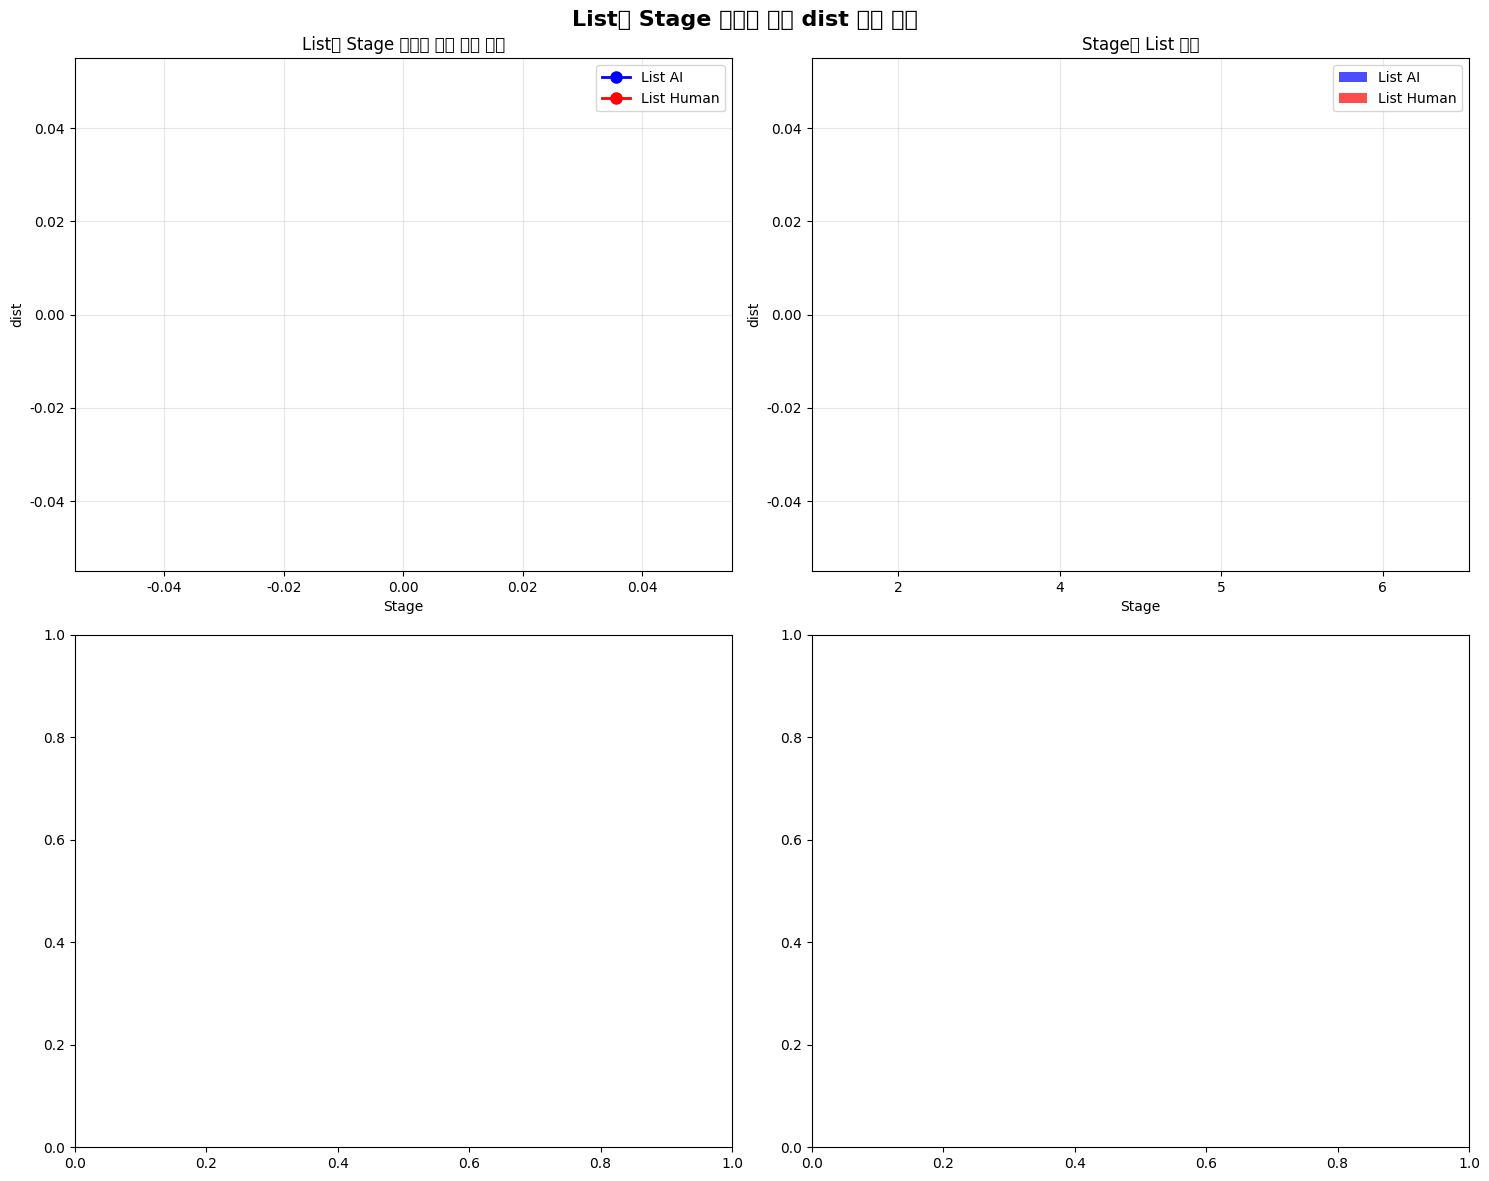


=== 추세 분석 요약 ===
=== List별 추세 차이 통계적 유의성 검정 ===

1. List x Stage 상호작용 효과 검정
ANOVA 테이블:
                         sum_sq     df         F    PR(>F)
actual_list        3.167123e+03    1.0  0.145519  0.702938
stage              2.064604e+04    3.0  0.316206  0.813676
actual_list:stage  1.698644e+04    3.0  0.260157  0.854111
Residual           2.115495e+07  972.0       NaN       NaN

List x Stage 상호작용 p-value: 0.8541
결과: List별 추세 차이가 통계적으로 유의미하지 않습니다 (p >= 0.05)

2. 각 List별 추세 유의성 검정

--- List AI ---
데이터가 부족하여 추세 분석을 수행할 수 없습니다.

--- List Human ---
데이터가 부족하여 추세 분석을 수행할 수 없습니다.

3. List별 추세 기울기 비교


In [42]:
# 실제 분석 실행을 위한 코드
# 위에서 확인한 컬럼명들을 바탕으로 추세 분석을 수행합니다.


# 추세 분석 실행 예시
dist_metric = 'dist'  # 실제 dist metric 컬럼명으로 변경
list_column = 'actual_list'         # 실제 list 컬럼명으로 변경  
stage_column = 'stage'       # 실제 stage 컬럼명으로 변경

# 1. 추세 분석 수행
results, stage_order = analyze_trend_by_list_stage(analysis_df, dist_metric, list_column, stage_column)

# 2. 시각화
visualize_trend_comparison(results, stage_order, dist_metric)

# 3. 통계적 유의성 검정
slopes = statistical_significance_test(analysis_df, dist_metric, list_column, stage_column)

